# GeoWatch Copilot




## 0. Install dependencies

In [1]:
!pip install -q transformers timm einops geopandas shapely scipy pillow matplotlib seaborn scikit-learn
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q huggingface_hub

print('Dependencies installed.')


Dependencies installed.


## 1. Load data from Drive

One cell. Mounts Drive, copies annotations/tiles/result.json and the OSM roads/waterways
geojson (from each run's `osm/` subfolder) into `/content/data/{city}/`, then auto-discovers
which cities are actually usable and pulls their AOI bounding boxes from `result.json`.

Update `CITY_MAP` below if your run IDs change.


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, shutil, json

DRIVE_BASE = '/content/drive/MyDrive/Geowatch'
DATA_ROOT = '/content/data'

CITY_MAP = {
    'dharavi': 'dharavi_20260702_163012',
    'nairobi': 'nairobi_20260702_164731',
    'jakarta': 'jakarta_20260702_163609',
    'hcmc':    'hcmc_20260702_163714',
    'kigali':  'kigali_20260702_163814',
    'accra':   'accra_20260702_163854',
    'dhaka':     'dhaka_20260702_163939',
    'lagos':     'lagos_20260702_165430',
    'capetown':  'capetown_20260702_164022',
    'guatemala': 'guatemala_20260702_164206',
    'nusantara': 'nusantara_20260702_165811',
    }

os.makedirs(DATA_ROOT, exist_ok=True)

# tile_0_0.png location differs between pipeline versions:
#   - original 5 cities: run_dir/tile_0_0.png
#   - new 6 cities:       run_dir/tiles/tile_0_0.png
TILE_SUBPATHS = ['tile_0_0.png', 'tiles/tile_0_0.png']

MAIN_FILES_NO_TILE = ['annotations.json', 'result.json']
OSM_FILES = ['roads.geojson', 'waterways.geojson']

for city, run_id in CITY_MAP.items():
    run_dir = f'{DRIVE_BASE}/{run_id}'
    dst_dir = f'{DATA_ROOT}/{city}'
    os.makedirs(dst_dir, exist_ok=True)

    if not os.path.isdir(run_dir):
        print(f'X {city}: run dir not found at {run_dir} -- skipping')
        continue

    copied, missing = [], []

    for f in MAIN_FILES_NO_TILE:
        src_path = f'{run_dir}/{f}'
        if os.path.isfile(src_path):
            shutil.copy(src_path, f'{dst_dir}/{f}')
            copied.append(f)
        else:
            missing.append(f)

    tile_found = False
    for sub in TILE_SUBPATHS:
        src_path = f'{run_dir}/{sub}'
        if os.path.isfile(src_path):
            shutil.copy(src_path, f'{dst_dir}/tile_0_0.png')
            copied.append(f'tile_0_0.png (from {sub})')
            tile_found = True
            break
    if not tile_found:
        missing.append('tile_0_0.png (checked: ' + ', '.join(TILE_SUBPATHS) + ')')

    osm_dir = f'{run_dir}/osm'
    for f in OSM_FILES:
        src_path = f'{osm_dir}/{f}'
        if os.path.isfile(src_path):
            shutil.copy(src_path, f'{dst_dir}/{f}')
            copied.append(f'osm/{f}')
        else:
            missing.append(f'osm/{f}')

    status = 'OK' if not missing else f'partial (missing: {missing})'
    print(f'{city:<10} <- {run_id:<26} [{status}]  copied: {copied}')

print('\nData load complete.')

Mounted at /content/drive
dharavi    <- dharavi_20260702_163012    [OK]  copied: ['annotations.json', 'result.json', 'tile_0_0.png (from tiles/tile_0_0.png)', 'osm/roads.geojson', 'osm/waterways.geojson']
nairobi    <- nairobi_20260702_164731    [OK]  copied: ['annotations.json', 'result.json', 'tile_0_0.png (from tiles/tile_0_0.png)', 'osm/roads.geojson', 'osm/waterways.geojson']
jakarta    <- jakarta_20260702_163609    [OK]  copied: ['annotations.json', 'result.json', 'tile_0_0.png (from tiles/tile_0_0.png)', 'osm/roads.geojson', 'osm/waterways.geojson']
hcmc       <- hcmc_20260702_163714       [OK]  copied: ['annotations.json', 'result.json', 'tile_0_0.png (from tiles/tile_0_0.png)', 'osm/roads.geojson', 'osm/waterways.geojson']
kigali     <- kigali_20260702_163814     [OK]  copied: ['annotations.json', 'result.json', 'tile_0_0.png (from tiles/tile_0_0.png)', 'osm/roads.geojson', 'osm/waterways.geojson']
accra      <- accra_20260702_163854      [OK]  copied: ['annotations.json', 're

In [3]:
missing_road_osm = []
missing_water_osm = []

for city, run_id in CITY_MAP.items():
    # -- road OSM-generated annotations (paved_road, from generate_osm_road_masks.py
    #    / merge_osm_road_masks.py) --
    road_src = f'{DRIVE_BASE}/{run_id}/osm_generated_annotations.json'
    road_dst = f'{DATA_ROOT}/{city}/osm_generated_annotations.json'
    if os.path.isfile(road_src):
        shutil.copy(road_src, road_dst)
        road_status = 'OK'
    else:
        missing_road_osm.append(city)
        road_status = 'MISSING'

    # -- water OSM-generated annotations (standing_water, from
    #    generate_osm_water_masks.py / merge_osm_water_masks.py -- NEW) --
    water_src = f'{DRIVE_BASE}/{run_id}/osm_generated_annotations_water.json'
    water_dst = f'{DATA_ROOT}/{city}/osm_generated_annotations_water.json'
    if os.path.isfile(water_src):
        shutil.copy(water_src, water_dst)
        water_status = 'OK'
    else:
        missing_water_osm.append(city)
        water_status = 'MISSING'

    print(f'{city:<10} <- {run_id:<26} '
          f'[road:{road_status:<7}] [water:{water_status:<7}]')

print()
if missing_road_osm:
    print(f'{len(missing_road_osm)} cities missing osm_generated_annotations.json '
          f'(road): {missing_road_osm}')
else:
    print('All 11 cities have osm_generated_annotations.json (road).')

if missing_water_osm:
    print(f'{len(missing_water_osm)} cities missing '
          f'osm_generated_annotations_water.json (water): {missing_water_osm}')
    print('  -> if this is unexpected, check that generate_osm_water_masks.py +')
    print('     merge_osm_water_masks.py were run locally AND that the resulting')
    print('     osm_generated_annotations_water.json files were uploaded to')
    print(f'     {DRIVE_BASE}/<run_id>/ before this cell ran.')
else:
    print('All 11 cities have osm_generated_annotations_water.json (water).')


dharavi    <- dharavi_20260702_163012    [OK]  copied osm_generated_annotations.json
nairobi    <- nairobi_20260702_164731    [OK]  copied osm_generated_annotations.json
jakarta    <- jakarta_20260702_163609    [OK]  copied osm_generated_annotations.json
hcmc       <- hcmc_20260702_163714       [OK]  copied osm_generated_annotations.json
kigali     <- kigali_20260702_163814     [OK]  copied osm_generated_annotations.json
accra      <- accra_20260702_163854      [OK]  copied osm_generated_annotations.json
dhaka      <- dhaka_20260702_163939      [OK]  copied osm_generated_annotations.json
lagos      <- lagos_20260702_165430      [OK]  copied osm_generated_annotations.json
capetown   <- capetown_20260702_164022   [OK]  copied osm_generated_annotations.json
guatemala  <- guatemala_20260702_164206  [OK]  copied osm_generated_annotations.json
nusantara  <- nusantara_20260702_165811  [OK]  copied osm_generated_annotations.json

All 11 cities copied successfully.


## 1b. Verify and auto-discover

In [4]:
import os, json

DATA_ROOT = '/content/data'

# ALL 11 cities now verified to have real mask_rle annotations (confirmed
# via the per-city mask_rle sanity check: total == with_mask_rle for
# every city, and via the label-canvas check: "N real masks, 0 bbox
# fallback"). CITY_MAP in cell 4 has been updated to point every city at
# its new (post-mask-fix) run_id -- no more restriction needed.
LOCO_CLEAN_CITIES = [
    'dharavi',
    'accra',
    'nairobi',
    'jakarta',
    'hcmc',
    'kigali',
    'dhaka',
    'lagos',
    'capetown',
    'guatemala',
    'nusantara',
]

CITIES = [
    city for city in LOCO_CLEAN_CITIES
    if os.path.isfile(f'{DATA_ROOT}/{city}/annotations.json')
    and os.path.isfile(f'{DATA_ROOT}/{city}/tile_0_0.png')
]

missing = set(LOCO_CLEAN_CITIES) - set(CITIES)
if missing:
    print(f"⚠ WARNING: expected 11 clean cities but these are missing files: {missing}")
    print(f"  Check CITY_MAP in cell 4 points to the new run_ids and Drive sync ran.")

print(f"Found {len(CITIES)}/11 clean cities for LOCO: {CITIES}")

# Pull bboxes from result.json instead of hardcoding
CITY_BBOXES = {}
for city in CITIES:
    result_path = f'{DATA_ROOT}/{city}/result.json'
    if os.path.isfile(result_path):
        with open(result_path) as f:
            aoi = json.load(f)['aoi']
        CITY_BBOXES[city] = [aoi['west'], aoi['south'], aoi['east'], aoi['north']]
        print(f"  ✓ {city}: bbox loaded")
    else:
        print(f"  ⚠ {city}: no result.json — OSM patches will be skipped")

print(f"\nReady. {len(CITY_BBOXES)} cities with bboxes.")

if len(CITIES) < 11:
    print("\n⚠ Stopping point: fix the missing cities above before proceeding to LOCO --")
    print("  a fold count below 11 changes what the LOCO loop below expects, and means")
    print("  some city's annotations.json or masks.json didn't sync from Drive correctly.")

Found 11/11 clean cities for LOCO: ['dharavi', 'accra', 'nairobi', 'jakarta', 'hcmc', 'kigali', 'dhaka', 'lagos', 'capetown', 'guatemala', 'nusantara']
  ✓ dharavi: bbox loaded
  ✓ accra: bbox loaded
  ✓ nairobi: bbox loaded
  ✓ jakarta: bbox loaded
  ✓ hcmc: bbox loaded
  ✓ kigali: bbox loaded
  ✓ dhaka: bbox loaded
  ✓ lagos: bbox loaded
  ✓ capetown: bbox loaded
  ✓ guatemala: bbox loaded
  ✓ nusantara: bbox loaded

Ready. 11 cities with bboxes.


## 2. Category definitions

In [5]:
# 7 ML-resolvable land-cover categories.
# unpaved_dirt_road, open_drainage_channel, open_waste are INTENTIONALLY
# excluded -- per project decision, these are physically unresolvable at
# Sentinel-2 10m resolution and are handled via OSM vector proximity
# labeling in the pipeline (osm_dem.py), not ML classification.
# Do not add them back into SegFormer training.
CATEGORIES = [
    'dense_informal_roofing',   # 0
    'sparse_informal_roofing',  # 1
    'paved_road',                # 2
    'standing_water',            # 3
    'vegetation_clearing',       # 4
    'active_construction',       # 5
    'dense_vegetation',          # 6
]
CAT2IDX = {c: i for i, c in enumerate(CATEGORIES)}
NUM_CLASSES = len(CATEGORIES)

# Label index 255 = ignore (unknown / unannotated pixels)
IGNORE_INDEX = 255

# NOTE: class weights are computed later (section 4) from the ACTUAL built
# patch dataset, not from annotation counts alone -- OSM-rasterized patches
# add hundreds of paved_road samples that annotation-only counts don't see.
# Computing weights before the dataset exists caused a real bug earlier
# (paved_road was both 77% of the data AND given the highest loss weight,
# which made the model collapse to predicting it everywhere). Do not
# reintroduce a pre-dataset CLASS_WEIGHTS computation here.

print(f'{NUM_CLASSES} categories defined: {CATEGORIES}')


7 categories defined: ['dense_informal_roofing', 'sparse_informal_roofing', 'paved_road', 'standing_water', 'vegetation_clearing', 'active_construction', 'dense_vegetation']


## 3. Dataset construction — five sources

- **SAM**: human-annotated segment crops (real per-pixel masks, all 7 ML categories)
- **OSM (live-rasterized)**: paved roads only (major road types: primary/secondary/
  tertiary/trunk/motorway), rasterized on the fly from each city's roads.geojson
  (unpaved_dirt_road / open_drainage_channel / open_waste are excluded -- OSM vector
  proximity handles those in the production pipeline instead, not SegFormer training)
- **OSM-generated (road)**: real, geometrically-correct paved_road masks pre-generated
  from OSM road-vector geometry (`generate_osm_road_masks.py` / `merge_osm_road_masks.py`),
  covering ALL paved road types including residential/unclassified/service roads --
  the dominant road type inside dense informal settlements, which the live-rasterized
  OSM source above never captured. This was the fix for the paved_road /
  dense_informal_roofing confusion.
- **OSM-generated (water) — NEW**: real, geometrically-correct standing_water masks
  pre-generated from OSM water geometry (`generate_osm_water_masks.py` /
  `merge_osm_water_masks.py`), covering both waterway centerlines (rivers/streams/
  canals/drains) AND natural=water / water=* polygon extents (lakes/ponds/reservoirs,
  including large river banks that centerlines alone miss -- confirmed necessary via
  a visual check on Dhaka, where centerline-only coverage was 0.1% of tile despite an
  unmistakably large river in frame; adding polygon coverage brought that to 5.7%).
  This is the Track A fix for standing_water being one of the three thinnest classes.
- **Sliding window**: dense crops sliced from each city's real per-pixel label canvas
  (built from all annotated segments), labeled by majority category within the window

All five sources write patch dicts with `image`, `mask`, `city`, `source`, `label` --
`source` is used later (Section 12 / cell 44) purely for provenance/auditing, never
for training logic, consistent with the project's standard of not hiding where
training data actually came from.


In [6]:
import json
import numpy as np
from PIL import Image
from pathlib import Path
import geopandas as gpd
from shapely.geometry import MultiLineString, LineString
import random

random.seed(42)
np.random.seed(42)

def decode_mask_rle(rle: dict) -> np.ndarray:
    """Matches ingestion/segmentation.py's encoder -- keep in sync."""
    h, w = rle["size"]
    counts = rle["counts"]
    flat = np.zeros(h * w, dtype=bool)
    idx = 0
    val = False
    for c in counts:
        if val:
            flat[idx:idx + c] = True
        idx += c
        val = not val
    return flat.reshape(w, h).T


def build_sam_patches(city: str, patch_size: int = 64) -> list:
    """
    CHANGED: uses the real SAM mask (mask_rle) to paint only the
    segment's actual shape as its label; everything else in the crop
    is IGNORE_INDEX, same philosophy as the OSM road patches. Falls
    back to the old full-bbox behavior only if mask_rle is missing
    (older annotations.json without the mask fix applied).
    """
    ann_path = Path(f'/content/data/{city}/annotations.json')
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')

    if not ann_path.exists() or not tile_path.exists():
        print(f'  [{city}] missing annotations.json or tile, skipping.')
        return []

    with open(ann_path) as f:
        ann_data = json.load(f)

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size

    patches_out = []
    skipped, unknown, excluded, no_mask = 0, 0, 0, 0

    for ann in ann_data['annotations']:
        if ann.get('skipped', False) or ann.get('human_label') is None:
            skipped += 1
            continue
        if ann['human_label'] == 'unknown':
            unknown += 1
            continue
        if ann['human_label'] not in CAT2IDX:
            excluded += 1
            continue

        x, y, w, h = ann['bbox']
        x1, y1 = max(0, x), max(0, y)
        x2, y2 = min(tile_w, x + w), min(tile_h, y + h)
        if x2 <= x1 or y2 <= y1:
            continue

        crop = tile_img.crop((x1, y1, x2, y2)).resize((patch_size, patch_size), Image.BILINEAR)
        crop_arr = np.array(crop, dtype=np.uint8)
        label_idx = CAT2IDX[ann['human_label']]

        mask_rle = ann.get('mask_rle')
        if mask_rle is not None:
            full_mask = decode_mask_rle(mask_rle)          # full tile-resolution boolean mask
            local_mask = full_mask[y1:y2, x1:x2]            # crop to this segment's bbox
            local_mask_img = Image.fromarray(local_mask.astype(np.uint8) * 255)
            local_mask_resized = local_mask_img.resize((patch_size, patch_size), Image.NEAREST)
            local_mask_arr = np.array(local_mask_resized) > 127

            label_mask = np.full((patch_size, patch_size), IGNORE_INDEX, dtype=np.uint8)
            label_mask[local_mask_arr] = label_idx
        else:
            no_mask += 1
            label_mask = np.full((patch_size, patch_size), label_idx, dtype=np.uint8)

        patches_out.append({
            'image': crop_arr,
            'mask': label_mask,
            'city': city,
            'source': 'sam',
            'label': ann['human_label'],
        })

    print(f'  [{city}] SAM patches: {len(patches_out)} usable | {skipped} skipped | '
          f'{unknown} unknown excluded | {excluded} OSM-only-category excluded | '
          f'{no_mask} used bbox fallback (no mask_rle)')
    return patches_out


def build_osm_patches(city: str, patch_size: int = 64, road_buffer_px: int = 2) -> list:
    """
    Source 2: OSM-derived training masks -- PAVED ROADS ONLY.

    This version now labels ONLY pixels within `road_buffer_px` of the traced
    road line as paved_road. Everything else in the crop is set to
    IGNORE_INDEX (excluded from loss) rather than guessed at -- we don't
    know what those other pixels are just because they're near a road.

    unpaved_dirt_road and open_drainage_channel rasterization remains REMOVED
    -- those categories are handled via OSM vector proximity in the
    production pipeline (osm_dem.py), not SegFormer classification.

    NOTE: this source only covers PAVED_TYPES = primary/secondary/tertiary/
    trunk/motorway (+ links) -- it deliberately does NOT include residential/
    unclassified/service roads. build_osm_generated_patches (below) covers
    those, using real buffered-geometry masks instead of thin traced lines.
    """
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')
    roads_path = Path(f'/content/data/{city}/roads.geojson')

    if not tile_path.exists():
        return []

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size
    tile_arr = np.array(tile_img, dtype=np.uint8)

    west, south, east, north = CITY_BBOXES[city]
    lon_per_px = (east - west) / tile_w
    lat_per_px = (north - south) / tile_h

    aoi_km2 = (east - west) * 111 * (north - south) * 111
    sample_stride = max(20, int(aoi_km2 * 2))
    print(f'  [{city}] AOI ~{aoi_km2:.1f} km^2 -> road_stride={sample_stride}')

    def lon_to_px(lon):
        return (lon - west) / lon_per_px

    def lat_to_py(lat):
        return (north - lat) / lat_per_px

    PAVED_TYPES = {'primary', 'secondary', 'tertiary', 'trunk', 'motorway',
                   'primary_link', 'secondary_link', 'tertiary_link'}

    patches_out = []
    half = patch_size // 2

    def rasterize_lines(gdf, label_idx, label_name, stride):
        road_pixels = []
        all_road_pixels_global = []
        for _, row in gdf.iterrows():
            geom = row.geometry
            if geom is None:
                continue
            if isinstance(geom, MultiLineString):
                line_list = list(geom.geoms)
            elif isinstance(geom, LineString):
                line_list = [geom]
            else:
                continue

            for line in line_list:
                try:
                    coords = list(line.coords)
                except Exception:
                    continue
                for i in range(len(coords) - 1):
                    x0 = lon_to_px(coords[i][0])
                    y0 = lat_to_py(coords[i][1])
                    x1 = lon_to_px(coords[i+1][0])
                    y1 = lat_to_py(coords[i+1][1])
                    n = max(int(np.hypot(x1-x0, y1-y0)) * 2, 2)
                    xs = np.linspace(x0, x1, n)
                    ys = np.linspace(y0, y1, n)
                    for x, y in zip(xs, ys):
                        xi, yi = int(round(x)), int(round(y))
                        all_road_pixels_global.append((xi, yi))
                        if half <= xi < tile_w - half and half <= yi < tile_h - half:
                            road_pixels.append((xi, yi))

        if not road_pixels:
            return []

        road_pixel_set = set(all_road_pixels_global)

        sampled = road_pixels[::stride]
        result = []
        for cx, cy in sampled:
            crop_arr = tile_arr[cy-half:cy+half, cx-half:cx+half]
            if crop_arr.shape[:2] != (patch_size, patch_size):
                continue

            label_mask = np.full((patch_size, patch_size), IGNORE_INDEX, dtype=np.uint8)
            for rx, ry in road_pixel_set:
                if (cx - half - road_buffer_px) <= rx <= (cx + half + road_buffer_px) and \
                   (cy - half - road_buffer_px) <= ry <= (cy + half + road_buffer_px):
                    local_x = rx - (cx - half)
                    local_y = ry - (cy - half)
                    x_lo = max(0, local_x - road_buffer_px)
                    x_hi = min(patch_size, local_x + road_buffer_px + 1)
                    y_lo = max(0, local_y - road_buffer_px)
                    y_hi = min(patch_size, local_y + road_buffer_px + 1)
                    if x_hi > x_lo and y_hi > y_lo:
                        label_mask[y_lo:y_hi, x_lo:x_hi] = label_idx

            if not (label_mask == label_idx).any():
                continue

            result.append({
                'image': crop_arr,
                'mask': label_mask,
                'city': city,
                'source': 'osm',
                'label': label_name,
            })
        return result

    if roads_path.exists():
        try:
            roads_gdf = gpd.read_file(roads_path)
            hw_col = 'highway' if 'highway' in roads_gdf.columns else None
            if hw_col:
                paved = roads_gdf[roads_gdf[hw_col].isin(PAVED_TYPES)]
                if not paved.empty:
                    p = rasterize_lines(paved, CAT2IDX['paved_road'], 'paved_road', sample_stride)
                    PAVED_ROAD_CAP_PER_CITY = 25
                    if len(p) > PAVED_ROAD_CAP_PER_CITY:
                        p = random.sample(p, PAVED_ROAD_CAP_PER_CITY)
                    patches_out.extend(p)
                    print(f'  [{city}] OSM paved road patches: {len(p)} '
                          f'(thin-line masks, buffer={road_buffer_px}px, capped at {PAVED_ROAD_CAP_PER_CITY})')
            else:
                print(f'  [{city}] roads.geojson has no highway column -- columns: {list(roads_gdf.columns)}')
        except Exception as e:
            print(f'  [{city}] roads.geojson error: {e}')
    else:
        print(f'  [{city}] roads.geojson not found')

    if not patches_out:
        print(f'  [{city}] No OSM patches generated')

    return patches_out


def build_osm_generated_patches(city: str, patch_size: int = 64,
                                 max_per_city: int = 25) -> list:
    """
    Source 4: real, geometrically-correct paved_road masks generated
    directly from OSM road-vector geometry (see generate_osm_road_masks.py
    / merge_osm_road_masks.py), bypassing SAM entirely for this class.
    Same schema as annotations.json (mask_rle, human_label, bbox), so
    this mirrors build_sam_patches's logic almost exactly.

    Unlike build_osm_patches (PAVED_TYPES only: primary/secondary/
    tertiary/trunk/motorway), this source covers ALL paved road types
    including residential/unclassified/service roads -- the dominant
    road type inside dense informal settlements, which the original
    build_osm_patches never captured. This is the actual fix for the
    paved_road/dense_informal_roofing confusion traced back to too few
    real paved_road training examples.

    CAPPED AT 25/city (275 max across 11 cities) -- deliberately kept at
    the SAME scale as build_osm_patches's existing cap, not larger. The
    underlying road_mask can have 100+ real segments per city (up to 192
    in Cape Town); this only samples a small, spatially-spread subset,
    specifically to avoid recreating the exact "one source dominates the
    dataset" imbalance problem this project already fixed once before.

    NOTE: combined with build_osm_patches, paved_road can now get up to
    ~50 patches/city from OSM sources alone (25+25), before SAM or
    sliding-window patches add more. Check the printed label_dist output
    after running the full assembly cell below -- if paved_road ends up
    disproportionately larger than every other class, lower max_per_city
    here (or in build_osm_patches) rather than assuming it's fine.

    Sampling is spatially spread (greedy farthest-point-style selection
    by segment centroid) rather than pure random -- prevents ending up
    with 25 patches that are all crops of the same one long road, which
    would teach the model that one road's specific look, not roads in
    general.
    """
    ann_path = Path(f'/content/data/{city}/osm_generated_annotations.json')
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')

    if not ann_path.exists() or not tile_path.exists():
        print(f'  [{city}] no osm_generated_annotations.json, skipping.')
        return []

    with open(ann_path) as f:
        ann_data = json.load(f)

    anns = [a for a in ann_data['annotations']
            if not a.get('skipped', False)
            and a.get('human_label') in CAT2IDX]

    if not anns:
        print(f'  [{city}] no usable OSM-generated segments.')
        return []

    def centroid(ann):
        x, y, w, h = ann['bbox']
        return (x + w / 2, y + h / 2)

    if len(anns) > max_per_city:
        random.shuffle(anns)
        selected = [anns.pop()]
        while len(selected) < max_per_city and anns:
            sel_centroids = [centroid(a) for a in selected]
            best_idx, best_dist = 0, -1
            for i, a in enumerate(anns):
                cx, cy = centroid(a)
                min_dist = min(
                    (cx - sx) ** 2 + (cy - sy) ** 2 for sx, sy in sel_centroids
                )
                if min_dist > best_dist:
                    best_dist, best_idx = min_dist, i
            selected.append(anns.pop(best_idx))
        anns = selected

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size

    patches_out = []
    for ann in anns:
        x, y, w, h = ann['bbox']
        x1, y1 = max(0, x), max(0, y)
        x2, y2 = min(tile_w, x + w), min(tile_h, y + h)
        if x2 <= x1 or y2 <= y1:
            continue

        crop = tile_img.crop((x1, y1, x2, y2)).resize((patch_size, patch_size), Image.BILINEAR)
        crop_arr = np.array(crop, dtype=np.uint8)
        label_idx = CAT2IDX[ann['human_label']]

        full_mask = decode_mask_rle(ann['mask_rle'])
        local_mask = full_mask[y1:y2, x1:x2]
        local_mask_img = Image.fromarray(local_mask.astype(np.uint8) * 255)
        local_mask_resized = local_mask_img.resize((patch_size, patch_size), Image.NEAREST)
        local_mask_arr = np.array(local_mask_resized) > 127

        label_mask = np.full((patch_size, patch_size), IGNORE_INDEX, dtype=np.uint8)
        label_mask[local_mask_arr] = label_idx

        patches_out.append({
            'image': crop_arr,
            'mask': label_mask,
            'city': city,
            'source': 'osm_generated',
            'label': ann['human_label'],
        })

    print(f'  [{city}] OSM-generated road patches: {len(patches_out)} '
          f'(spatially-spread sample, capped at {max_per_city})')
    return patches_out


def build_osm_generated_water_patches(city: str, patch_size: int = 64,
                                       max_per_city: int = 25) -> list:
    """
    Source 5 (NEW): real, geometrically-correct standing_water masks
    generated directly from OSM water geometry (see
    generate_osm_water_masks.py / merge_osm_water_masks.py), bypassing
    SAM entirely for this class -- direct mirror of
    build_osm_generated_patches (Source 4, paved_road) above, same
    schema (mask_rle, human_label, bbox), just pointed at
    osm_generated_annotations_water.json and standing_water instead.

    WHY THIS EXISTS: standing_water was one of the three genuinely thin
    classes (~30 SAM-annotated segments total across all 11 cities, per
    Track A prioritization). Unlike active_construction and
    sparse_informal_roofing, standing_water has a real OSM shortcut --
    water bodies (waterway lines AND natural=water / water=* polygons)
    are geometrically defined in OSM the same way roads are, so this
    source rasterizes them directly rather than requiring new manual
    annotation.

    CAPPED AT 25/city, same rationale and same cap value as
    build_osm_generated_patches -- deliberately NOT larger, to avoid
    recreating the "one source dominates the dataset" imbalance problem
    this project already fixed once for paved_road. In practice this cap
    only binds for cities with unusually dense OSM water coverage (e.g.
    Nusantara, which had 31 real segments after connected-component
    generation -- everything else came in well under 25: Dhaka 22,
    Dharavi 17, Lagos 8, Jakarta 7, Nairobi 4, Cape Town 5, Accra 3,
    Guatemala 2, HCMC 2, Kigali 0). Kigali producing 0 usable segments
    here is a real, known gap (its OSM water geometry was too fragmented
    -- all components fell below the 15px noise-filter in
    merge_osm_water_masks.py), not a bug in this function; standing_water
    for Kigali will still rely on whatever SAM/sliding-window coverage
    exists for it, if any.

    Same spatially-spread (greedy farthest-point) sampling as the road
    version when over cap, for the same reason -- avoids 25 patches that
    are all crops of the same one pond/canal.
    """
    ann_path = Path(f'/content/data/{city}/osm_generated_annotations_water.json')
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')

    if not ann_path.exists() or not tile_path.exists():
        print(f'  [{city}] no osm_generated_annotations_water.json, skipping.')
        return []

    with open(ann_path) as f:
        ann_data = json.load(f)

    anns = [a for a in ann_data['annotations']
            if not a.get('skipped', False)
            and a.get('human_label') in CAT2IDX]

    if not anns:
        print(f'  [{city}] no usable OSM-generated water segments.')
        return []

    def centroid(ann):
        x, y, w, h = ann['bbox']
        return (x + w / 2, y + h / 2)

    if len(anns) > max_per_city:
        random.shuffle(anns)
        selected = [anns.pop()]
        while len(selected) < max_per_city and anns:
            sel_centroids = [centroid(a) for a in selected]
            best_idx, best_dist = 0, -1
            for i, a in enumerate(anns):
                cx, cy = centroid(a)
                min_dist = min(
                    (cx - sx) ** 2 + (cy - sy) ** 2 for sx, sy in sel_centroids
                )
                if min_dist > best_dist:
                    best_dist, best_idx = min_dist, i
            selected.append(anns.pop(best_idx))
        anns = selected

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size

    patches_out = []
    for ann in anns:
        x, y, w, h = ann['bbox']
        x1, y1 = max(0, x), max(0, y)
        x2, y2 = min(tile_w, x + w), min(tile_h, y + h)
        if x2 <= x1 or y2 <= y1:
            continue

        crop = tile_img.crop((x1, y1, x2, y2)).resize((patch_size, patch_size), Image.BILINEAR)
        crop_arr = np.array(crop, dtype=np.uint8)
        label_idx = CAT2IDX[ann['human_label']]

        full_mask = decode_mask_rle(ann['mask_rle'])
        local_mask = full_mask[y1:y2, x1:x2]
        local_mask_img = Image.fromarray(local_mask.astype(np.uint8) * 255)
        local_mask_resized = local_mask_img.resize((patch_size, patch_size), Image.NEAREST)
        local_mask_arr = np.array(local_mask_resized) > 127

        label_mask = np.full((patch_size, patch_size), IGNORE_INDEX, dtype=np.uint8)
        label_mask[local_mask_arr] = label_idx

        patches_out.append({
            'image': crop_arr,
            'mask': label_mask,
            'city': city,
            'source': 'osm_generated_water',
            'label': ann['human_label'],
        })

    print(f'  [{city}] OSM-generated water patches: {len(patches_out)} '
          f'(spatially-spread sample, capped at {max_per_city})')
    return patches_out


def build_tile_label_canvas(city: str) -> tuple:
    """
    Paints every annotated segment's REAL per-pixel mask onto a single
    full-tile-resolution label canvas, once per city.

    Segments are painted LARGEST-AREA-FIRST, then smaller segments are
    painted on top -- so a small precise object doesn't get silently
    swallowed by a much larger overlapping mask that happens to share
    pixels with it.

    Falls back to painting the segment's full bbox only if mask_rle is
    missing (older annotations.json without the mask fix).

    Returns:
        (canvas, tile_w, tile_h) where canvas is a (tile_h, tile_w)
        uint8 array, IGNORE_INDEX where no annotated segment covers
        that pixel, else the CAT2IDX label for whichever segment
        "wins" that pixel.
    """
    ann_path = Path(f'/content/data/{city}/annotations.json')
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')

    if not ann_path.exists() or not tile_path.exists():
        return None, 0, 0

    with open(ann_path) as f:
        ann_data = json.load(f)

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size

    canvas = np.full((tile_h, tile_w), IGNORE_INDEX, dtype=np.uint8)

    usable = []
    for ann in ann_data['annotations']:
        if ann.get('skipped', False) or ann.get('human_label') is None:
            continue
        if ann['human_label'] == 'unknown':
            continue
        if ann['human_label'] not in CAT2IDX:
            continue
        usable.append(ann)

    usable.sort(key=lambda a: a.get('area', 0), reverse=True)

    n_real_mask, n_bbox_fallback = 0, 0

    for ann in usable:
        label_idx = CAT2IDX[ann['human_label']]
        x, y, w, h = ann['bbox']
        x1, y1 = max(0, x), max(0, y)
        x2, y2 = min(tile_w, x + w), min(tile_h, y + h)
        if x2 <= x1 or y2 <= y1:
            continue

        mask_rle = ann.get('mask_rle')
        if mask_rle is not None:
            full_mask = decode_mask_rle(mask_rle)  # (tile_h, tile_w) bool
            canvas[full_mask] = label_idx
            n_real_mask += 1
        else:
            canvas[y1:y2, x1:x2] = label_idx
            n_bbox_fallback += 1

    print(f'  [{city}] Label canvas built: {n_real_mask} real masks, '
          f'{n_bbox_fallback} bbox fallback, {len(usable)} total segments painted')

    return canvas, tile_w, tile_h


def build_sliding_window_patches(city: str, patch_size: int = 64, stride: int = 32,
                                  min_labeled_pct: float = 5.0,
                                  max_per_class_per_city: int = 30) -> list:
    """
    Source 3: Sliding window patches, sliced from the real per-pixel
    label canvas (see build_tile_label_canvas).

    max_per_class_per_city caps how many sliding-window patches of ANY
    SINGLE class a city can contribute, same rationale as the OSM caps
    above. Subsampled (not truncated) when over the cap.
    """
    from collections import defaultdict

    canvas, tile_w, tile_h = build_tile_label_canvas(city)
    if canvas is None:
        return []

    tile_path = Path(f'/content/data/{city}/tile_0_0.png')
    tile_img = Image.open(tile_path).convert('RGB')
    tile_arr = np.array(tile_img, dtype=np.uint8)

    candidates_by_label = defaultdict(list)
    min_labeled_px = int(patch_size * patch_size * min_labeled_pct / 100.0)

    for y_start in range(0, tile_h - patch_size, stride):
        for x_start in range(0, tile_w - patch_size, stride):
            x_end = x_start + patch_size
            y_end = y_start + patch_size

            label_mask = canvas[y_start:y_end, x_start:x_end]
            n_labeled = (label_mask != IGNORE_INDEX).sum()
            if n_labeled < min_labeled_px:
                continue

            crop_arr = tile_arr[y_start:y_end, x_start:x_end]

            vals, counts = np.unique(label_mask[label_mask != IGNORE_INDEX], return_counts=True)
            dominant_idx = int(vals[np.argmax(counts)]) if len(vals) else IGNORE_INDEX
            dominant_label = CATEGORIES[dominant_idx] if dominant_idx != IGNORE_INDEX else 'unknown'

            candidates_by_label[dominant_label].append({
                'image': crop_arr,
                'mask': label_mask.copy(),
                'city': city,
                'source': 'sliding_window',
                'label': dominant_label,
            })

    patches_out = []
    capped_summary = []
    for label, items in candidates_by_label.items():
        if len(items) > max_per_class_per_city:
            kept = random.sample(items, max_per_class_per_city)
            capped_summary.append(f'{label}: {len(items)}->{max_per_class_per_city}')
        else:
            kept = items
        patches_out.extend(kept)

    cap_note = f' | capped: {", ".join(capped_summary)}' if capped_summary else ''
    print(f'  [{city}] Sliding window patches: {len(patches_out)} '
          f'(min {min_labeled_pct}% coverage, max {max_per_class_per_city}/class){cap_note}')
    return patches_out

Build the full dataset from all cities:

In [7]:
from collections import Counter

all_patches = []

print('Building dataset from all cities...')
for city in CITIES:
    print(f'\n--- {city.upper()} ---')
    all_patches.extend(build_sam_patches(city))
    all_patches.extend(build_osm_patches(city))
    all_patches.extend(build_osm_generated_patches(city))
    all_patches.extend(build_osm_generated_water_patches(city))  # NEW -- standing_water
    all_patches.extend(build_sliding_window_patches(city))

print(f'\nRaw total: {len(all_patches)} patches')

# -- Label distribution --
label_dist = Counter(p['label'] for p in all_patches)
source_dist = Counter(p['source'] for p in all_patches)

print('\nLabel distribution:')
for cat in CATEGORIES:
    count = label_dist.get(cat, 0)
    bar = chr(9608) * min(count // 2, 40)
    print(f'  {cat:<30} {count:>4}  {bar}')

print('\nSource distribution:')
for src, count in source_dist.items():
    print(f'  {src:<20} {count}')

# NOTE: oversampling step has been REMOVED. With the 3 OSM-only
# categories (unpaved_dirt_road, open_drainage_channel, open_waste)
# now excluded from training, the remaining imbalance is handled by
# CLASS_WEIGHTS (inverse-frequency weighted CE) alone. Running both
# oversampling AND class weighting in the same direction was what
# caused the model to over-predict the rarest classes. Use only one.

random.shuffle(all_patches)

for label in CATEGORIES:
    if label_dist.get(label, 0) == 0:
        print(f'  WARNING: {label} has 0 patches -- will be ignored in training')

print(f'\nFinal: {len(all_patches)} patches (no oversampling applied)')


Building dataset from all cities...

--- DHARAVI ---
  [dharavi] SAM patches: 32 usable | 0 skipped | 4 unknown excluded | 3 OSM-only-category excluded | 0 used bbox fallback (no mask_rle)
  [dharavi] AOI ~7.4 km^2 -> road_stride=20
  [dharavi] OSM paved road patches: 25 (thin-line masks, buffer=2px, capped at 25)
  [dharavi] OSM-generated road patches: 25 (spatially-spread sample, capped at 25)
  [dharavi] Label canvas built: 32 real masks, 0 bbox fallback, 32 total segments painted
  [dharavi] Sliding window patches: 40 (min 5.0% coverage, max 30/class)

--- ACCRA ---
  [accra] SAM patches: 18 usable | 0 skipped | 3 unknown excluded | 4 OSM-only-category excluded | 0 used bbox fallback (no mask_rle)
  [accra] AOI ~12.9 km^2 -> road_stride=25
  [accra] OSM paved road patches: 25 (thin-line masks, buffer=2px, capped at 25)
  [accra] OSM-generated road patches: 25 (spatially-spread sample, capped at 25)
  [accra] Label canvas built: 18 real masks, 0 bbox fallback, 18 total segments pain

## 3b. Sanity check — are OSM `paved_road` patches actually degenerate?

`paved_road` gets ~800 patches from OSM rasterization vs a handful from SAM/sliding-window,
and it scores the best F1 of any class. Before assuming that's a data-leakage / degenerate-pattern
artifact (repeated near-identical crops), actually look at a random sample. If these patches show
real visual variety (different road widths, angles, surroundings), the high F1 is plausibly a
genuinely easier class, not leakage -- don't "fix" a problem that isn't there.


Total OSM paved_road patches: 275


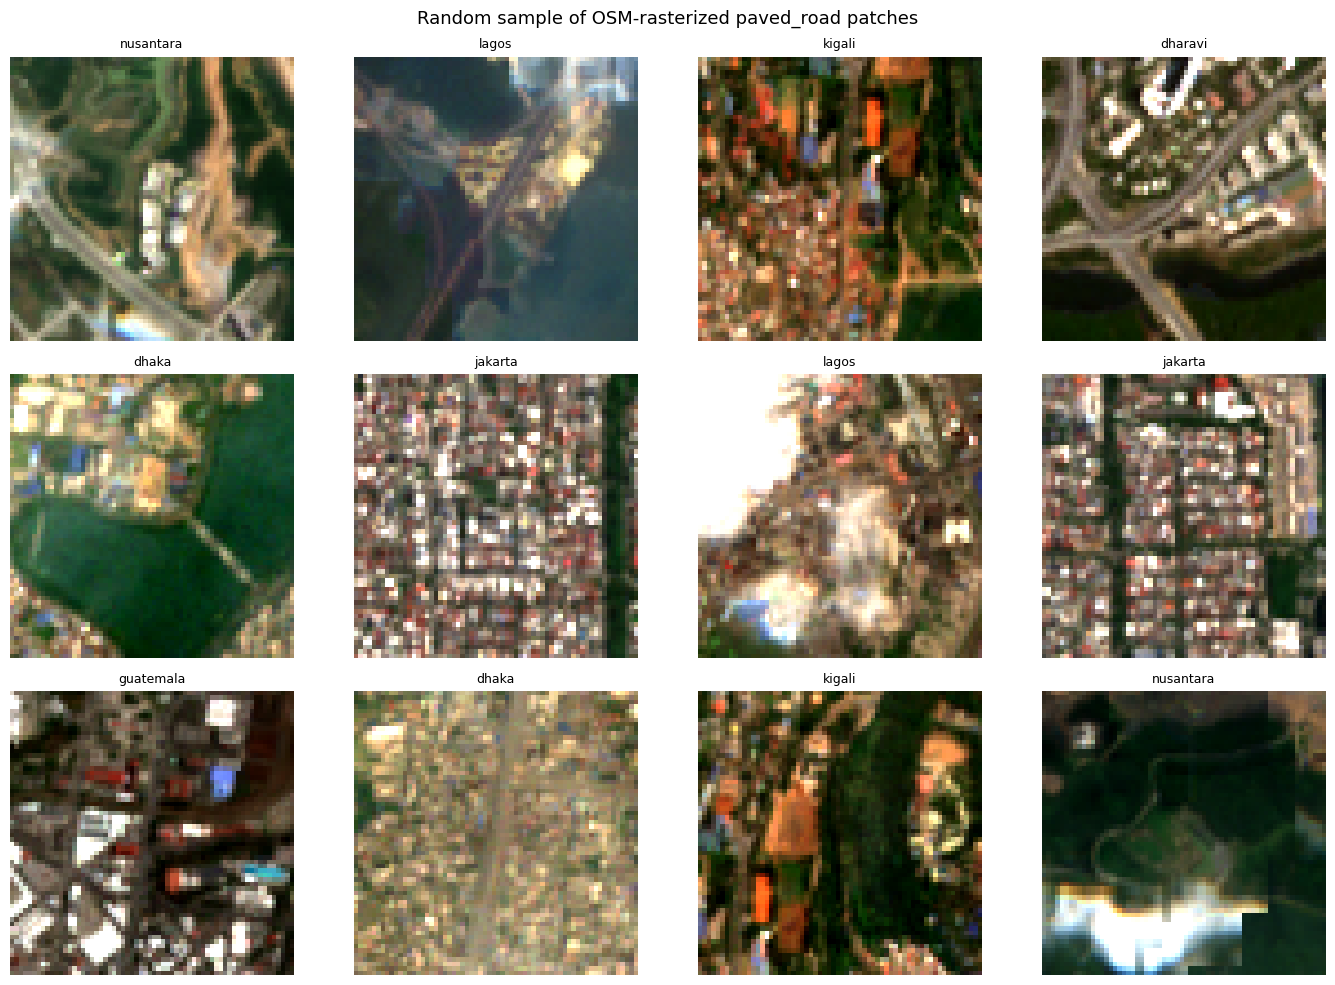


Look at the grid above:
  - Real variety (different roads, angles, surroundings, lighting) -> genuinely easier
    class, F1 is plausibly real. No fix needed here.
  - Near-identical crops (same framing repeated) -> genuine degeneracy. If so, fix by
    varying crop size/angle/offset in build_osm_patches(), not just capping volume.


In [8]:
import random
import matplotlib.pyplot as plt

osm_paved = [p for p in all_patches if p['source'] == 'osm' and p['label'] == 'paved_road']
print(f'Total OSM paved_road patches: {len(osm_paved)}')

if osm_paved:
    sample = random.sample(osm_paved, min(12, len(osm_paved)))
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    for ax, p in zip(axes.flat, sample):
        ax.imshow(p['image'])
        ax.set_title(p['city'], fontsize=9)
        ax.axis('off')
    for ax in axes.flat[len(sample):]:
        ax.axis('off')
    plt.suptitle('Random sample of OSM-rasterized paved_road patches', fontsize=13)
    plt.tight_layout()
    plt.savefig('/content/osm_patch_sample.png', dpi=150)
    plt.show()
    print('\nLook at the grid above:')
    print('  - Real variety (different roads, angles, surroundings, lighting) -> genuinely easier')
    print('    class, F1 is plausibly real. No fix needed here.')
    print('  - Near-identical crops (same framing repeated) -> genuine degeneracy. If so, fix by')
    print('    varying crop size/angle/offset in build_osm_patches(), not just capping volume.')
else:
    print('No OSM paved_road patches found -- check roads.geojson availability per city.')


  [dharavi] Label canvas built: 32 real masks, 0 bbox fallback, 32 total segments painted
  [dharavi] Sliding window patches: 40 (min 5.0% coverage, max 30/class)

Total Dharavi sliding-window patches: 40
Windows with 2+ distinct labels (mixed): 31
Windows with exactly 1 label:            9


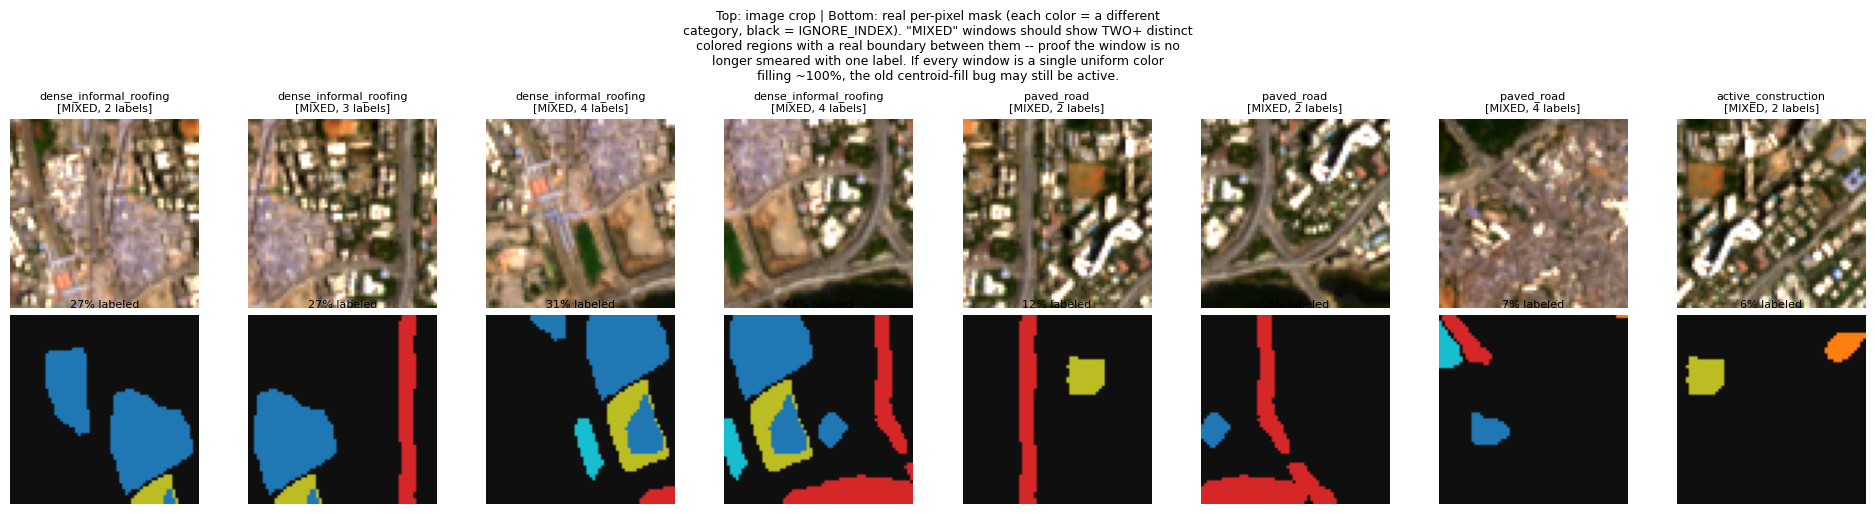


Color legend:
  dense_informal_roofing       RGB(31,119,180)
  sparse_informal_roofing      RGB(255,127,14)
  paved_road                   RGB(214,39,40)
  standing_water               RGB(140,86,75)
  vegetation_clearing          RGB(227,119,194)
  active_construction          RGB(188,189,34)
  dense_vegetation             RGB(23,190,207)


In [9]:
# ============================================================
# VALIDATION CELL — sliding-window fix
# Paste this AFTER build_tile_label_canvas / build_sliding_window_patches
# are defined. Checks Dharavi specifically (the only city with real
# masks right now).
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

dharavi_sw_patches = build_sliding_window_patches('dharavi')
print(f'\nTotal Dharavi sliding-window patches: {len(dharavi_sw_patches)}')

# Find patches with MIXED labels -- i.e. more than one real category
# present in the same window, plus (usually) some IGNORE_INDEX. This is
# the actual proof the fix works: the old bug could never produce this,
# every window was 100% one label. Sort by "most mixed" first so the
# clearest examples show up.
def n_unique_labels(mask):
    vals = np.unique(mask[mask != IGNORE_INDEX])
    return len(vals)

mixed = [p for p in dharavi_sw_patches if n_unique_labels(p['mask']) >= 2]
single = [p for p in dharavi_sw_patches if n_unique_labels(p['mask']) == 1]

print(f'Windows with 2+ distinct labels (mixed): {len(mixed)}')
print(f'Windows with exactly 1 label:            {len(single)}')

if len(mixed) == 0:
    print('\n  ⚠️  No mixed-label windows found. This can happen legitimately if')
    print('  Dharavi\'s segments are large/sparse relative to the 64px window and')
    print('  stride -- not necessarily a bug. But it does mean this check can\'t')
    print('  confirm the mixed-label path specifically. Falling back to showing')
    print('  single-label windows so you can at least confirm mask shape is real')
    print('  (irregular, matching image content) rather than a uniform fill.')

# Build the sample: prioritize mixed-label windows, fill remainder with
# single-label ones so you still get a reasonable grid either way.
sample = mixed[:8] if mixed else single[:8]

if not sample:
    print('No sliding-window patches to visualize.')
else:
    n = len(sample)
    fig, axes = plt.subplots(2, n, figsize=(2.4 * n, 5.2))
    if n == 1:
        axes = axes.reshape(2, 1)

    # Distinct colors per category index for the mask visualization
    palette = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))[:, :3] * 255

    for i, p in enumerate(sample):
        axes[0, i].imshow(p['image'])
        n_labels = n_unique_labels(p['mask'])
        tag = 'MIXED' if n_labels >= 2 else 'single'
        axes[0, i].set_title(f"{p['label']}\n[{tag}, {n_labels} labels]", fontsize=8)
        axes[0, i].axis('off')

        mask = p['mask']
        vis = np.zeros((*mask.shape, 3), dtype=np.uint8)
        vis[:] = [15, 15, 15]  # IGNORE_INDEX background
        for cls_idx in np.unique(mask):
            if cls_idx == IGNORE_INDEX:
                continue
            vis[mask == cls_idx] = palette[cls_idx].astype(np.uint8)

        labeled_pct = 100 * (mask != IGNORE_INDEX).sum() / mask.size
        axes[1, i].imshow(vis)
        axes[1, i].set_title(f'{labeled_pct:.0f}% labeled', fontsize=8)
        axes[1, i].axis('off')

    plt.suptitle(
        'Top: image crop | Bottom: real per-pixel mask (each color = a different\n'
        'category, black = IGNORE_INDEX). "MIXED" windows should show TWO+ distinct\n'
        'colored regions with a real boundary between them -- proof the window is no\n'
        'longer smeared with one label. If every window is a single uniform color\n'
        'filling ~100%, the old centroid-fill bug may still be active.',
        fontsize=9
    )
    plt.tight_layout()
    plt.show()

    # Legend
    print('\nColor legend:')
    for idx, cat in enumerate(CATEGORIES):
        r, g, b = palette[idx].astype(int)
        print(f'  {cat:28s} RGB({r},{g},{b})')

## 4. Class weights

Computed from the **actual built dataset** (`all_patches`), not from annotation counts alone.
This is the one and only place CLASS_WEIGHTS gets defined -- computing it earlier from
annotation-only counts caused a real bug (see note above).


In [10]:
from collections import Counter
import numpy as np
import torch

actual_counts = Counter(p['label'] for p in all_patches)
counts = np.array([actual_counts.get(c, 1) for c in CATEGORIES], dtype=np.float32)
counts = np.maximum(counts, 1)
weights = 1.0 / counts
weights = weights / weights.sum() * NUM_CLASSES
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float32)

print('Recomputed class weights from ACTUAL patch counts:')
for cat, w, c in zip(CATEGORIES, CLASS_WEIGHTS, counts):
    print(f'  {cat:<30} count={int(c):>4}  weight={w:.3f}')

Recomputed class weights from ACTUAL patch counts:
  dense_informal_roofing         count= 161  weight=0.547
  sparse_informal_roofing        count=  30  weight=2.933
  paved_road                     count= 587  weight=0.150
  standing_water                 count= 107  weight=0.822
  vegetation_clearing            count=  70  weight=1.257
  active_construction            count=  91  weight=0.967
  dense_vegetation               count= 272  weight=0.324


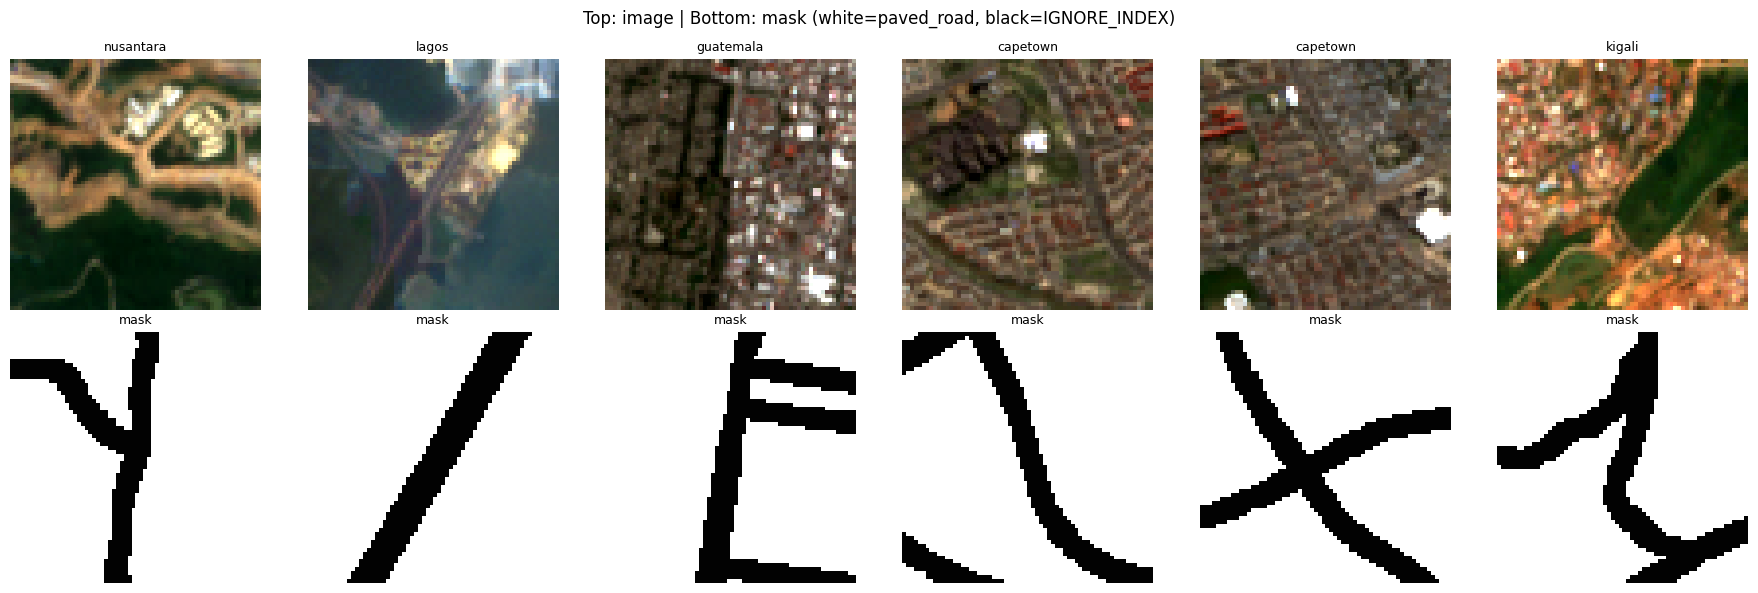

In [11]:
import matplotlib.pyplot as plt

osm_paved = [p for p in all_patches if p['source'] == 'osm' and p['label'] == 'paved_road']
sample = osm_paved[:6]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, p in enumerate(sample):
    axes[0, i].imshow(p['image'])
    axes[0, i].set_title(p['city'], fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(p['mask'], cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title('mask', fontsize=9)
    axes[1, i].axis('off')
plt.suptitle('Top: image | Bottom: mask (white=paved_road, black=IGNORE_INDEX)')
plt.tight_layout()
plt.show()

## 5. Data augmentation and PyTorch Dataset

Train patches: 1219 (cities: accra, capetown, dhaka, dharavi, guatemala, hcmc, jakarta, lagos, nairobi, nusantara)
Val patches:   99 (city: kigali — LOCO held-out)

Train batches: 77
Val batches:   7


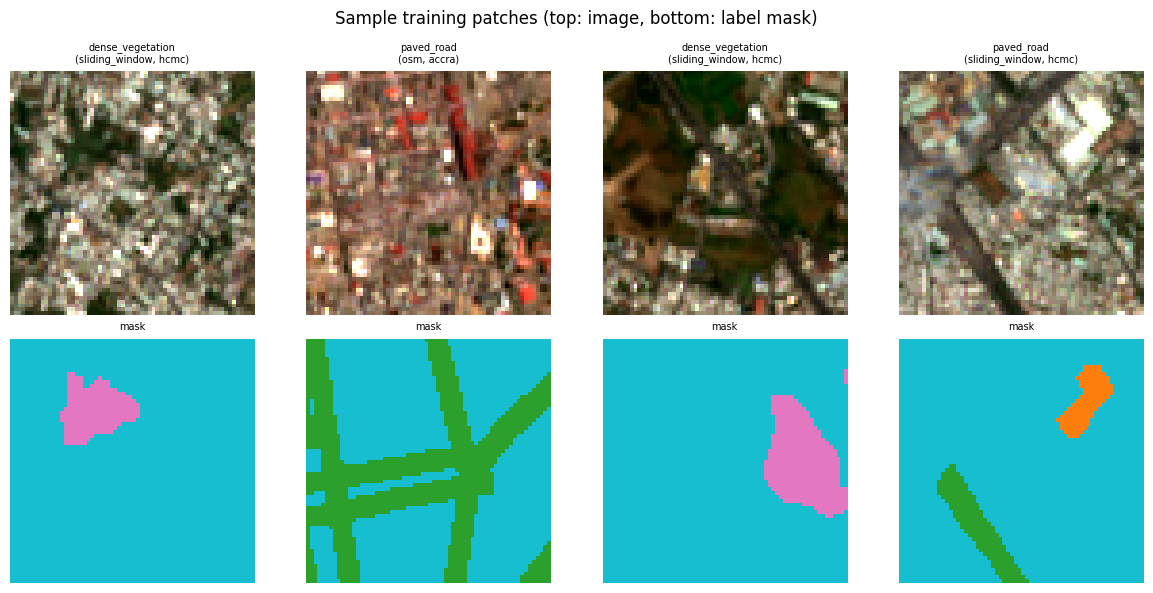

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random
import matplotlib.pyplot as plt

PATCH_SIZE = 64


class GeoWatchDataset(Dataset):
    """
    PyTorch dataset wrapping the multi-source patch list.
    Applies augmentation during training.

    Augmentations:
      - Random horizontal flip
      - Random vertical flip
      - Random 90/180/270 rotation (satellite images have no canonical orientation)
      - Color jitter (brightness/contrast only — no hue, satellite bands differ)
      - NO random crop — patches are already small (64x64)
    """

    def __init__(self, patches: list, augment: bool = True):
        self.patches = patches
        self.augment = augment

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        item = self.patches[idx]
        image = torch.from_numpy(item['image']).permute(2, 0, 1).float() / 255.0  # (3, H, W)
        mask = torch.from_numpy(item['mask']).long()  # (H, W)

        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask.unsqueeze(0)).squeeze(0)

            # Random vertical flip
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask.unsqueeze(0)).squeeze(0)

            # Random 90-degree rotation
            k = random.randint(0, 3)
            if k > 0:
                image = torch.rot90(image, k, dims=[1, 2])
                mask = torch.rot90(mask, k, dims=[0, 1])

            # Color jitter — brightness and contrast only
            if random.random() > 0.5:
                brightness = random.uniform(0.8, 1.2)
                contrast = random.uniform(0.8, 1.2)
                image = TF.adjust_brightness(image, brightness)
                image = TF.adjust_contrast(image, contrast)
                image = image.clamp(0, 1)

        # Normalize with ImageNet mean/std (reasonable for RGB satellite tiles)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = (image - mean) / std

        return image, mask


# Train/val split — hold out all Jakarta patches for LOCO validation
# (Leave-One-City-Out: train on 4 cities, validate on held-out city)
VAL_CITY = 'kigali'
train_patches = [p for p in all_patches if p['city'] != VAL_CITY]
val_patches = [p for p in all_patches if p['city'] == VAL_CITY]

train_cities = sorted(set(p['city'] for p in train_patches))
print(f'Train patches: {len(train_patches)} (cities: {", ".join(train_cities)})')
print(f'Val patches:   {len(val_patches)} (city: {VAL_CITY} — LOCO held-out)')

train_dataset = GeoWatchDataset(train_patches, augment=True)
val_dataset = GeoWatchDataset(val_patches, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

# Sanity check — visualize 4 random training patches
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    idx = random.randint(0, len(train_patches)-1)
    p = train_patches[idx]
    axes[0, i].imshow(p['image'])
    axes[0, i].set_title(f"{p['label']}\n({p['source']}, {p['city']})", fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(p['mask'], cmap='tab10', vmin=0, vmax=9)
    axes[1, i].set_title('mask', fontsize=7)
    axes[1, i].axis('off')
plt.suptitle('Sample training patches (top: image, bottom: label mask)')
plt.tight_layout()
plt.show()

**6. ResNet50 (Sentinel-2 RGB pretrained) + DeepLabV3+-style decoder**


In [13]:
!pip install -q torchgeo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 871.8/871.8 kB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [14]:
# ============================================================
# GeoWatch Copilot — Encoder swap: ImageNet SegFormer-B2 (frozen)
# -> ResNet50 pretrained on Sentinel-2 RGB (torchgeo SSL4EO-S12 MoCo)
#
# WHY: SegFormer-B2's mit-b2 encoder was ImageNet-1k pretrained (natural
# photos) and fully frozen -- the decoder was trying to recover satellite
# boundaries from features that have never seen a satellite image. Clay
# v1 was correctly rejected (flat ViT, incompatible with hierarchical
# encoders). This swap uses a real satellite-domain-pretrained backbone
# instead: torchgeo/resnet50_sentinel2_rgb_moco, verified on HuggingFace,
# trained via MoCo directly on Sentinel-2 RGB imagery (SSL4EO-S12).


# %% CELL — Model: ResNet50 (Sentinel-2 RGB pretrained) + DeepLabV3+-style decoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchgeo.models import ResNet50_Weights, resnet50


class ASPP(nn.Module):
    """
    Atrous Spatial Pyramid Pooling -- standard DeepLabV3+ component.
    Captures multi-scale context from the high-level feature map.
    """
    def __init__(self, in_channels: int, out_channels: int = 256, rates=(1, 6, 12, 18)):
        super().__init__()
        self.branches = nn.ModuleList()
        for rate in rates:
            if rate == 1:
                self.branches.append(nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(inplace=True),
                ))
            else:
                self.branches.append(nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, kernel_size=3,
                              padding=rate, dilation=rate, bias=False),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(inplace=True),
                ))
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * (len(rates) + 1), out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        size = x.shape[-2:]
        feats = [branch(x) for branch in self.branches]
        pooled = self.pool(x)
        pooled = F.interpolate(pooled, size=size, mode='bilinear', align_corners=False)
        feats.append(pooled)
        x = torch.cat(feats, dim=1)
        return self.project(x)


class DeepLabDecoder(nn.Module):
    """
    DeepLabV3+ decoder: ASPP on high-level features, fused with a
    low-level skip connection for boundary detail, upsampled to input res.
    """
    def __init__(self, low_level_channels: int, high_level_channels: int,
                 num_classes: int, aspp_channels: int = 256, low_level_proj: int = 48):
        super().__init__()
        self.aspp = ASPP(high_level_channels, out_channels=aspp_channels)
        self.low_level_proj = nn.Sequential(
            nn.Conv2d(low_level_channels, low_level_proj, kernel_size=1, bias=False),
            nn.BatchNorm2d(low_level_proj),
            nn.ReLU(inplace=True),
        )
        self.fuse = nn.Sequential(
            nn.Conv2d(aspp_channels + low_level_proj, aspp_channels, kernel_size=3,
                      padding=1, bias=False),
            nn.BatchNorm2d(aspp_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(aspp_channels, aspp_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(aspp_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )
        self.classifier = nn.Conv2d(aspp_channels, num_classes, kernel_size=1)

    def forward(self, low_level_feat, high_level_feat, target_size):
        x = self.aspp(high_level_feat)
        x = F.interpolate(x, size=low_level_feat.shape[-2:], mode='bilinear', align_corners=False)
        low = self.low_level_proj(low_level_feat)
        x = torch.cat([x, low], dim=1)
        x = self.fuse(x)
        x = self.classifier(x)
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
        return x


class GeoWatchResNetSeg(nn.Module):
    """
    ResNet50 encoder pretrained on Sentinel-2 RGB (torchgeo SSL4EO-S12
    MoCo weights) + DeepLabV3+-style decoder.

    freeze_encoder=False by default -- unlike the SegFormer setup, this
    encoder has already seen satellite imagery, so full fine-tuning is
    appropriate and is the actual fix (not a frozen-feature workaround).
    With ~900 patches, use a low encoder LR (see optimizer param groups
    in the training cell) rather than freezing outright.
    """
    def __init__(self, num_classes: int = 7, freeze_encoder: bool = False):
        super().__init__()

        self.encoder = resnet50(weights=ResNet50_Weights.SENTINEL2_RGB_MOCO)
        print('Loaded ResNet50 encoder: torchgeo SSL4EO-S12 MoCo, Sentinel-2 RGB pretrained.')

        # layer1 output: stride 4, 256 channels  -- low-level / boundary detail
        # layer3 output: stride 16, 1024 channels -- high-level semantics
        # (using layer3 instead of layer4/stride32 -- on 64x64 patches,
        # stride32 collapses to a 2x2 feature map, too coarse to be useful;
        # layer3 keeps a 4x4 map with still-substantial semantic depth)
        self._features = {}
        self.encoder.layer1.register_forward_hook(self._hook('low'))
        self.encoder.layer3.register_forward_hook(self._hook('high'))

        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
            print('Encoder frozen (not recommended for this backbone -- see docstring).')
        else:
            print('Encoder fully trainable (domain-matched pretraining -- use a low LR).')

        self.decoder = DeepLabDecoder(
            low_level_channels=256,
            high_level_channels=1024,
            num_classes=num_classes,
        )

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f'Parameters: {trainable:,} trainable / {total:,} total ({100*trainable/total:.1f}%)')

    def _hook(self, name):
        def fn(module, input, output):
            self._features[name] = output
        return fn

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        target_size = pixel_values.shape[-2:]
        self.encoder.forward_features(pixel_values) if hasattr(self.encoder, 'forward_features') \
            else self.encoder(pixel_values)
        low = self._features['low']
        high = self._features['high']
        return self.decoder(low, high, target_size)


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nDevice: {device}')
model = GeoWatchResNetSeg(num_classes=NUM_CLASSES, freeze_encoder=False).to(device)
print('Model ready.')


class GeoWatchDatasetResNet(GeoWatchDataset):
    """Same as GeoWatchDataset, but skips ImageNet mean/std normalization
    (see note above) -- only scales to [0,1], matching production tiles."""
    def __getitem__(self, idx):
        item = self.patches[idx]
        image = torch.from_numpy(item['image']).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(item['mask']).long()

        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask.unsqueeze(0)).squeeze(0)
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask.unsqueeze(0)).squeeze(0)
            k = random.randint(0, 3)
            if k > 0:
                image = torch.rot90(image, k, dims=[1, 2])
                mask = torch.rot90(mask, k, dims=[0, 1])
            if random.random() > 0.5:
                brightness = random.uniform(0.8, 1.2)
                contrast = random.uniform(0.8, 1.2)
                image = TF.adjust_brightness(image, brightness)
                image = TF.adjust_contrast(image, contrast)
                image = image.clamp(0, 1)

        return image, mask


print('GeoWatchDatasetResNet defined -- use this instead of GeoWatchDataset in run_loco_fold().')

print('Apply the 3 changes above to run_loco_fold(), then re-run the LOCO loop cell.')


Device: cuda
Downloading: "https://hf.co/torchgeo/resnet50_sentinel2_rgb_moco/resolve/efd9723b59a88e9dc1420dc1e96afb25b0630a3c/resnet50_sentinel2_rgb_moco-2b57ba8b.pth" to /root/.cache/torch/hub/checkpoints/resnet50_sentinel2_rgb_moco-2b57ba8b.pth


100%|██████████| 90.0M/90.0M [00:05<00:00, 17.7MB/s]


Loaded ResNet50 encoder: torchgeo SSL4EO-S12 MoCo, Sentinel-2 RGB pretrained.
Encoder fully trainable (domain-matched pretraining -- use a low LR).
Parameters: 34,795,407 trainable / 34,795,407 total (100.0%)
Model ready.
GeoWatchDatasetResNet defined -- use this instead of GeoWatchDataset in run_loco_fold().
Apply the 3 changes above to run_loco_fold(), then re-run the LOCO loop cell.


## 7. Loss functions -- CrossEntropy + Dice

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):
    """
    Multiclass Dice loss.
    Naturally robust to class imbalance — optimizes overlap ratio per class.
    Excludes IGNORE_INDEX pixels.
    """

    def __init__(self, num_classes: int, ignore_index: int = 255, smooth: float = 1.0):
        super().__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = F.softmax(logits, dim=1)  # (B, C, H, W)
        B, C, H, W = probs.shape

        valid_mask = (targets != self.ignore_index)  # (B, H, W)
        targets_clamped = targets.clone()
        targets_clamped[~valid_mask] = 0

        targets_one_hot = F.one_hot(targets_clamped, num_classes=C)  # (B, H, W, C)
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()  # (B, C, H, W)

        mask_expanded = valid_mask.unsqueeze(1).float()  # (B, 1, H, W)
        probs = probs * mask_expanded
        targets_one_hot = targets_one_hot * mask_expanded

        dice_per_class = []
        for c in range(C):
            p = probs[:, c].reshape(-1)
            t = targets_one_hot[:, c].reshape(-1)
            intersection = (p * t).sum()
            dice = (2.0 * intersection + self.smooth) / (p.sum() + t.sum() + self.smooth)
            dice_per_class.append(1.0 - dice)

        return torch.stack(dice_per_class).mean()


class CombinedLoss(nn.Module):
    """
    CrossEntropy + Dice, equal weighting, PLUS a targeted separation term
    between paved_road and dense_informal_roofing.

    ADDED this session to fix the confirmed confusion pair: 72.9% of all
    CAAT-unknown-mass pixels (pooled across Cape Town + Dharavi) were
    argmax-confused between exactly these two classes (see
    check_confusion_pair.py diagnostic). The separation term penalizes
    the model whenever a ground-truth paved_road or dense_informal_roofing
    pixel's OWN logit isn't at least `separation_margin` above the OTHER
    class's logit at that same pixel -- directly forcing the decoder to
    push these two apart, rather than leaving it to CE/Dice alone (which
    is what let this confusion persist in the first place). Does not
    affect any other class pair's loss.
    """

    def __init__(self, class_weights: torch.Tensor, ignore_index: int = 255,
                 dice_weight: float = 0.5,
                 separation_weight: float = 0.5, separation_margin: float = 2.0,
                 class_a_idx: int = None, class_b_idx: int = None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights, ignore_index=ignore_index)
        self.dice = DiceLoss(num_classes=len(class_weights), ignore_index=ignore_index)
        self.dice_weight = dice_weight
        self.ignore_index = ignore_index

        self.separation_weight = separation_weight
        self.separation_margin = separation_margin
        self.class_a_idx = class_a_idx  # paved_road
        self.class_b_idx = class_b_idx  # dense_informal_roofing

    def separation_loss(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        if self.class_a_idx is None or self.class_b_idx is None:
            return torch.tensor(0.0, device=logits.device)

        valid = targets != self.ignore_index
        logit_a = logits[:, self.class_a_idx, :, :]
        logit_b = logits[:, self.class_b_idx, :, :]

        is_a = valid & (targets == self.class_a_idx)
        is_b = valid & (targets == self.class_b_idx)

        loss = torch.tensor(0.0, device=logits.device)
        n_terms = 0

        if is_a.any():
            gap_a = logit_a[is_a] - logit_b[is_a]
            loss = loss + F.relu(self.separation_margin - gap_a).mean()
            n_terms += 1

        if is_b.any():
            gap_b = logit_b[is_b] - logit_a[is_b]
            loss = loss + F.relu(self.separation_margin - gap_b).mean()
            n_terms += 1

        return loss / n_terms if n_terms > 0 else torch.tensor(0.0, device=logits.device)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)
        sep_loss = self.separation_loss(logits, targets)

        total = ((1 - self.dice_weight) * ce_loss
                 + self.dice_weight * dice_loss
                 + self.separation_weight * sep_loss)
        return total, ce_loss, dice_loss, sep_loss


criterion = CombinedLoss(
    class_weights=CLASS_WEIGHTS.to(device),
    ignore_index=IGNORE_INDEX,
    dice_weight=0.5,
    separation_weight=0.5,
    separation_margin=2.0,
    class_a_idx=CATEGORIES.index('paved_road'),
    class_b_idx=CATEGORIES.index('dense_informal_roofing'),
)
print('Loss function ready: 0.5 * CrossEntropy (weighted) + 0.5 * Dice '
      '+ 0.5 * pair-separation (paved_road vs dense_informal_roofing)')

Loss function ready: 0.5 * CrossEntropy (weighted) + 0.5 * Dice + 0.5 * pair-separation (paved_road vs dense_informal_roofing)


In [16]:
import pickle
import os

DRIVE_DATASET_DIR = '/content/drive/MyDrive/Geowatch/datasets'
os.makedirs(DRIVE_DATASET_DIR, exist_ok=True)

dataset_path = f'{DRIVE_DATASET_DIR}/geowatch_dataset_{len(CITIES)}city.pkl'

with open(dataset_path, 'wb') as f:
    pickle.dump({
        'all_patches': all_patches,
        'cities': CITIES,
        'city_bboxes': CITY_BBOXES,
        'categories': CATEGORIES,
        'class_weights': CLASS_WEIGHTS,
        'num_classes': NUM_CLASSES,
        'ignore_index': IGNORE_INDEX,
    }, f)

print(f'Dataset saved: {dataset_path}')
print(f'  {len(all_patches)} total patches across {len(CITIES)} cities')

# Also copy to local Colab disk for a downloadable link this session
import shutil
local_copy = f'/content/geowatch_dataset_{len(CITIES)}city.pkl'
shutil.copy(dataset_path, local_copy)

from google.colab import files
print('\nTriggering download...')
files.download(local_copy)

Dataset saved: /content/drive/MyDrive/Geowatch/datasets/geowatch_dataset_11city.pkl
  1318 total patches across 11 cities

Triggering download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Training loop

In [17]:
import torch
print("CUDA:", torch.cuda.is_available())
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
torch.cuda.empty_cache()

CUDA: True
0.140845056 GB allocated


In [18]:
import shutil
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/Geowatch/checkpoints'
import os
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

In [19]:
print('Val batches:', len(val_loader))
print('Val dataset size:', len(val_loader.dataset))
val_labels = set()
for _, masks in val_loader:
    val_labels.update(masks.unique().tolist())
print('Classes present in val set:', sorted(val_labels))
print('Names:', [CATEGORIES[i] for i in sorted(val_labels) if i < NUM_CLASSES])

Val batches: 7
Val dataset size: 99
Classes present in val set: [0, 2, 4, 6, 255]
Names: ['dense_informal_roofing', 'paved_road', 'vegetation_clearing', 'dense_vegetation']


In [20]:
from tqdm.notebook import tqdm
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

optimizer = optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': 1e-5},
    {'params': model.decoder.parameters(), 'lr': 3e-4},
], weight_decay=1e-4)

NUM_EPOCHS = 50
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)


def freeze_bn_stats(module):
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            m.eval()


def compute_miou(logits: torch.Tensor, targets: torch.Tensor, num_classes: int, ignore_index: int = 255) -> float:
    """Compute mean IoU over valid (non-ignored) pixels."""
    preds = logits.argmax(dim=1)  # (B, H, W)
    valid = targets != ignore_index

    iou_per_class = []
    for c in range(num_classes):
        pred_c = (preds == c) & valid
        true_c = (targets == c) & valid
        intersection = (pred_c & true_c).sum().item()
        union = (pred_c | true_c).sum().item()
        if union == 0:
            continue
        iou_per_class.append(intersection / union)

    return float(np.mean(iou_per_class)) if iou_per_class else 0.0


def compute_per_class_iou(logits: torch.Tensor, targets: torch.Tensor, num_classes: int,
                           ignore_index: int = 255) -> dict:
    """
    Per-class IoU, not just the mean -- needed to specifically confirm
    whether paved_road / dense_informal_roofing improved, since that's
    the whole point of the separation loss (per-fold mean alone can hide
    whether THESE TWO classes specifically got better).
    """
    preds = logits.argmax(dim=1)
    valid = targets != ignore_index
    ious = {}
    for c in range(num_classes):
        pred_c = (preds == c) & valid
        true_c = (targets == c) & valid
        intersection = (pred_c & true_c).sum().item()
        union = (pred_c | true_c).sum().item()
        ious[c] = (intersection / union) if union > 0 else None
    return ious


train_losses = []
val_mious = []
best_val_miou = 0.0
best_epoch = 0

print(f'Training for {NUM_EPOCHS} epochs on {device}...')
print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} batches')
print('─' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──
    model.train()
    freeze_bn_stats(model.encoder)   # keep pretrained BN stats intact
    epoch_loss = 0.0
    epoch_ce = 0.0
    epoch_dice = 0.0
    epoch_sep = 0.0

    train_bar = tqdm(train_loader, desc=f'Epoch {epoch:3d}/{NUM_EPOCHS} [train]', leave=False)
    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss, ce_loss, dice_loss, sep_loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], max_norm=1.0
        )
        optimizer.step()

        epoch_loss += loss.item()
        epoch_ce += ce_loss.item()
        epoch_dice += dice_loss.item()
        epoch_sep += sep_loss.item()

        train_bar.set_postfix(loss=f'{loss.item():.4f}', sep=f'{sep_loss.item():.4f}')

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ── Validate ──
    model.eval()
    all_logits = []
    all_masks = []

    val_bar = tqdm(val_loader, desc=f'Epoch {epoch:3d}/{NUM_EPOCHS} [val]  ', leave=False)
    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu())
            all_masks.append(masks.cpu())

    if all_logits:
        all_logits_cat = torch.cat(all_logits, dim=0)
        all_masks_cat = torch.cat(all_masks, dim=0)
        val_miou = compute_miou(all_logits_cat, all_masks_cat, NUM_CLASSES, IGNORE_INDEX)
    else:
        val_miou = 0.0

    val_mious.append(val_miou)

    # Save best checkpoint
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_miou': val_miou,
            'categories': CATEGORIES,
            'num_classes': NUM_CLASSES,
        }, '/content/resnet_geowatch_best.pth')
        shutil.copy('/content/resnet_geowatch_best.pth', f'{DRIVE_CHECKPOINT_DIR}/resnet_geowatch_best.pth')

    # Print summary every epoch
    lr_enc = optimizer.param_groups[0]['lr']
    lr_dec = optimizer.param_groups[1]['lr']
    star = '★ best' if epoch == best_epoch else ''
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Loss={avg_loss:.4f} (CE={epoch_ce/len(train_loader):.4f}, '
          f'Dice={epoch_dice/len(train_loader):.4f}, Sep={epoch_sep/len(train_loader):.4f}) | '
          f'Val mIoU={val_miou:.4f} | LR_enc={lr_enc:.2e} LR_dec={lr_dec:.2e} | {star}')

# ── Final: per-class IoU on the best checkpoint's validation predictions ──
# Confirms whether paved_road / dense_informal_roofing specifically improved --
# not just whether the overall mean went up.
paved_idx = CATEGORIES.index('paved_road')
roofing_idx = CATEGORIES.index('dense_informal_roofing')
final_per_class_iou = compute_per_class_iou(all_logits_cat, all_masks_cat, NUM_CLASSES, IGNORE_INDEX)

print(f'\nTraining complete. Best val mIoU: {best_val_miou:.4f} at epoch {best_epoch}')
print(f'\nFinal-epoch per-class IoU (sanity check on the confusion pair specifically):')
for i, cat in enumerate(CATEGORIES):
    iou = final_per_class_iou.get(i)
    marker = '  <-- confusion pair' if i in (paved_idx, roofing_idx) else ''
    iou_str = f'{iou:.4f}' if iou is not None else 'N/A (no pixels this fold)'
    print(f'  {cat:<30} IoU={iou_str}{marker}')

Training for 50 epochs on cuda...
Train: 77 batches | Val: 7 batches
────────────────────────────────────────────────────────────


Epoch   1/50 [train]:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch   1/50 [val]  :   0%|          | 0/7 [00:00<?, ?it/s]

Epoch   1/50 | Loss=2.2235 (CE=1.7316, Dice=0.8287, Sep=1.8868) | Val mIoU=0.1249 | LR_enc=9.99e-06 LR_dec=3.00e-04 | ★ best


Epoch   2/50 [train]:   0%|          | 0/77 [00:00<?, ?it/s]

...

Epoch  49/50 [val]  :   0%|          | 0/7 [00:00<?, ?it/s]

Epoch  49/50 | Loss=0.2710 (CE=0.1707, Dice=0.3122, Sep=0.0591) | Val mIoU=0.2872 | LR_enc=1.01e-06 LR_dec=1.30e-06 | 


Epoch  50/50 [train]:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch  50/50 [val]  :   0%|          | 0/7 [00:00<?, ?it/s]

Epoch  50/50 | Loss=0.3058 (CE=0.1942, Dice=0.3364, Sep=0.0810) | Val mIoU=0.2933 | LR_enc=1.00e-06 LR_dec=1.00e-06 | 

Training complete. Best val mIoU: 0.3249 at epoch 30

Final-epoch per-class IoU (sanity check on the confusion pair specifically):
  dense_informal_roofing         IoU=0.2919  <-- confusion pair
  sparse_informal_roofing        IoU=0.0000
  paved_road                     IoU=0.5815  <-- confusion pair
  standing_water                 IoU=0.0000
  vegetation_clearing            IoU=0.4158
  active_construction            IoU=0.0000
  dense_vegetation               IoU=0.7637


## 9. Training curves

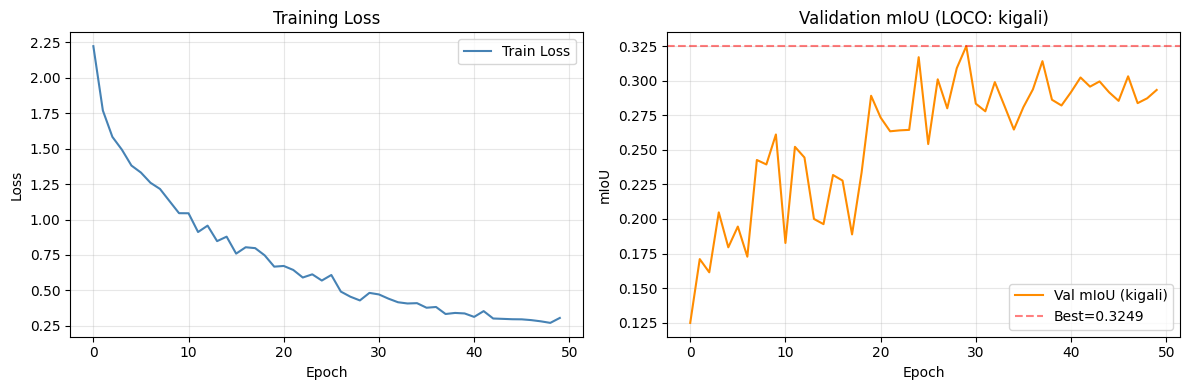

Saved: /content/training_curves.png


In [21]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_mious, label=f'Val mIoU ({VAL_CITY})', color='darkorange')
ax2.axhline(best_val_miou, color='red', linestyle='--', alpha=0.5, label=f'Best={best_val_miou:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mIoU')
ax2.set_title(f'Validation mIoU (LOCO: {VAL_CITY})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print('Saved: /content/training_curves.png')

In [23]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, f1_score


def freeze_bn_stats(module):
    """Puts BatchNorm layers into eval mode so running stats don't get
    overwritten by this fold's small batch statistics."""
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            m.eval()


def run_loco_fold(val_city: str, all_patches: list, num_epochs: int = 30,
                   patience: int = 8, batch_size: int = 16,
                   lr_encoder: float = 1e-5, lr_decoder: float = 3e-4,
                   verbose: bool = True) -> dict:
    """
    Trains a fresh GeoWatchResNetSeg with `val_city` held out, everything
    else as train. Early-stops on val mIoU plateau (patience epochs with
    no improvement).

    UPDATED this session: criterion now returns 4 values
    (total, ce, dice, sep) since CombinedLoss includes the paved_road /
    dense_informal_roofing separation term -- unpacking fixed accordingly.
    separation_weight lowered to 0.25 (from an earlier 0.5 test that
    overcorrected: paved_road IoU 0.6056 but dense_informal_roofing
    collapsed to 0.0733 on a single-fold sanity check).

    Returns a dict with per-fold results: best_miou, best_epoch,
    per_class_f1, confusion_matrix, classes_present, history.
    """
    train_patches = [p for p in all_patches if p['city'] != val_city]
    val_patches = [p for p in all_patches if p['city'] == val_city]

    if not val_patches:
        if verbose:
            print(f'  [{val_city}] SKIPPED -- no patches for this city')
        return None

    train_cities = sorted(set(p['city'] for p in train_patches))
    if verbose:
        print(f'\n{"="*60}')
        print(f'LOCO FOLD: held-out = {val_city}')
        print(f'  Train: {len(train_patches)} patches from {len(train_cities)} cities')
        print(f'  Val:   {len(val_patches)} patches ({val_city})')

    from collections import Counter
    fold_counts = Counter(p['label'] for p in train_patches)
    counts_arr = np.array([fold_counts.get(c, 1) for c in CATEGORIES], dtype=np.float32)
    counts_arr = np.maximum(counts_arr, 1)
    fold_weights = 1.0 / counts_arr
    fold_weights = fold_weights / fold_weights.sum() * NUM_CLASSES
    fold_class_weights = torch.tensor(fold_weights, dtype=torch.float32).to(device)

    train_loader = DataLoader(GeoWatchDatasetResNet(train_patches, augment=True),
                               batch_size=batch_size, shuffle=True,
                               num_workers=0, pin_memory=True,
                               drop_last=True)
    val_loader = DataLoader(GeoWatchDatasetResNet(val_patches, augment=False),
                             batch_size=batch_size, shuffle=False,
                             num_workers=0, pin_memory=True)

    model = GeoWatchResNetSeg(num_classes=NUM_CLASSES, freeze_encoder=False).to(device)
    criterion = CombinedLoss(
        class_weights=fold_class_weights,
        ignore_index=IGNORE_INDEX,
        dice_weight=0.5,
        separation_weight=0.25,     # lowered from 0.5 -- see docstring
        separation_margin=2.0,
        class_a_idx=CATEGORIES.index('paved_road'),
        class_b_idx=CATEGORIES.index('dense_informal_roofing'),
    )
    optimizer = optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': lr_encoder},
        {'params': model.decoder.parameters(), 'lr': lr_decoder},
    ], weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_miou = 0.0
    best_epoch = 0
    best_state = None
    epochs_since_improve = 0
    history = {'train_loss': [], 'val_miou': []}

    for epoch in range(1, num_epochs + 1):
        model.train()
        freeze_bn_stats(model.encoder)
        epoch_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss, _, _, _ = criterion(logits, masks)   # <-- FIXED: 4 values now
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        model.eval()
        all_logits, all_masks = [], []
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                logits = model(images)
                all_logits.append(logits.cpu())
                all_masks.append(masks.cpu())
        all_logits_cat = torch.cat(all_logits, dim=0)
        all_masks_cat = torch.cat(all_masks, dim=0)
        val_miou = compute_miou(all_logits_cat, all_masks_cat, NUM_CLASSES, IGNORE_INDEX)
        history['val_miou'].append(val_miou)

        if val_miou > best_miou:
            best_miou = val_miou
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1

        if verbose:
            star = ' best' if epoch == best_epoch else ''
            print(f'  epoch {epoch:3d}/{num_epochs} | loss={avg_loss:.4f} | '
                  f'val_mIoU={val_miou:.4f}{star}')

        if epochs_since_improve >= patience:
            if verbose:
                print(f'  Early stop at epoch {epoch} (no improvement for {patience} epochs)')
            break

    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(masks.numpy())
    all_preds = np.concatenate([p.flatten() for p in all_preds])
    all_targets = np.concatenate([t.flatten() for t in all_targets])

    valid = all_targets != IGNORE_INDEX
    all_preds = all_preds[valid]
    all_targets = all_targets[valid]

    classes_present = sorted(set(all_targets.tolist()))
    class_names_present = [CATEGORIES[c] for c in classes_present]

    cm = confusion_matrix(all_targets, all_preds, labels=classes_present, normalize='true')
    f1_per_class = f1_score(all_targets, all_preds, labels=classes_present, average=None)

    if verbose:
        print(f'  FOLD RESULT: best_mIoU={best_miou:.4f} @ epoch {best_epoch} '
              f'| classes present: {class_names_present}')

    del model
    torch.cuda.empty_cache()

    return {
        'val_city': val_city,
        'best_miou': best_miou,
        'best_epoch': best_epoch,
        'train_cities': train_cities,
        'n_train': len(train_patches),
        'n_val': len(val_patches),
        'classes_present': class_names_present,
        'per_class_f1': dict(zip(class_names_present, f1_per_class.tolist())),
        'confusion_matrix': cm,
        'confusion_labels': class_names_present,
        'history': history,
    }


print('run_loco_fold() defined (ResNet50 encoder, separation loss weight=0.25).')

run_loco_fold() defined (ResNet50 encoder, separation loss weight=0.25).


In [25]:
ALL_CITIES = sorted(set(p['city'] for p in all_patches))
print(f'Running LOCO across {len(ALL_CITIES)} cities: {ALL_CITIES}')
if len(ALL_CITIES) != 11:
    print(f'⚠ WARNING: expected 11 cities in all_patches, got {len(ALL_CITIES)}')
print('Early stopping (patience=8) means folds with fast convergence finish sooner.\n')

loco_results = {}
for city in ALL_CITIES:
    result = run_loco_fold(city, all_patches, num_epochs=30, patience=8, verbose=True)
    if result is not None:
        loco_results[city] = result

print(f'\n{"="*60}')
print(f'LOCO complete. {len(loco_results)}/{len(ALL_CITIES)} folds ran successfully.')

Running LOCO across 11 cities: ['accra', 'capetown', 'dhaka', 'dharavi', 'guatemala', 'hcmc', 'jakarta', 'kigali', 'lagos', 'nairobi', 'nusantara']
Early stopping (patience=8) means folds with fast convergence finish sooner.


LOCO FOLD: held-out = accra
  Train: 1221 patches from 10 cities
  Val:   97 patches (accra)
Loaded ResNet50 encoder: torchgeo SSL4EO-S12 MoCo, Sentinel-2 RGB pretrained.
Encoder fully trainable (domain-matched pretraining -- use a low LR).
Parameters: 34,795,407 trainable / 34,795,407 total (100.0%)
  epoch   1/30 | loss=1.3732 | val_mIoU=0.2205 best
  epoch   2/30 | loss=1.1054 | val_mIoU=0.2004
  epoch   3/30 | loss=0.9209 | val_mIoU=0.3046 best
  epoch   4/30 | loss=0.8509 | val_mIoU=0.2643
  epoch   5/30 | loss=0.7733 | val_mIoU=0.2749
  epoch   6/30 | loss=0.7235 | val_mIoU=0.2701
  epoch   7/30 | loss=0.6657 | val_mIoU=0.2615
  epoch   8/30 | loss=0.6030 | val_mIoU=0.2386
  epoch   9/30 | loss=0.5572 | val_mIoU=0.2744
  epoch  10/30 | loss=0.5388 | val_mIo

**10.** **PRODUCTION CELL
**

In [27]:
import copy
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from collections import Counter


def freeze_bn_stats(module):
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            m.eval()


PROD_NUM_EPOCHS = 40
PROD_PATIENCE = 10
PROD_BATCH_SIZE = 16
PROD_LR_ENCODER = 1e-5
PROD_LR_DECODER = 3e-4
PROD_VAL_FRACTION = 0.10

random.seed(42)

shuffled = all_patches.copy()
random.shuffle(shuffled)
n_val = max(1, int(len(shuffled) * PROD_VAL_FRACTION))
monitor_val_patches = shuffled[:n_val]
train_patches = shuffled[n_val:]

print(f'Production training set: {len(train_patches)} patches')
print(f'Monitoring split (random, not held-out-city): {len(monitor_val_patches)} patches')
print(f'Cities represented in training: {sorted(set(p["city"] for p in train_patches))}')
print('NOTE: this monitoring mIoU is NOT a generalization metric. The real')
print('generalization number is the fresh LOCO result you just ran above.\n')

full_counts = Counter(p['label'] for p in train_patches)
counts_arr = np.array([full_counts.get(c, 1) for c in CATEGORIES], dtype=np.float32)
counts_arr = np.maximum(counts_arr, 1)
prod_weights = 1.0 / counts_arr
prod_weights = prod_weights / prod_weights.sum() * NUM_CLASSES
PROD_CLASS_WEIGHTS = torch.tensor(prod_weights, dtype=torch.float32).to(device)
print('Class weights (production, full dataset):')
for cat, w in zip(CATEGORIES, prod_weights):
    print(f'  {cat:28s} {w:.4f}')

train_loader = DataLoader(GeoWatchDatasetResNet(train_patches, augment=True),
                           batch_size=PROD_BATCH_SIZE, shuffle=True,
                           num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(GeoWatchDatasetResNet(monitor_val_patches, augment=False),
                         batch_size=PROD_BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

model = GeoWatchResNetSeg(num_classes=NUM_CLASSES, freeze_encoder=False).to(device)
criterion = CombinedLoss(
    class_weights=PROD_CLASS_WEIGHTS,
    ignore_index=IGNORE_INDEX,
    dice_weight=0.5,
    separation_weight=0.25,     # lowered from 0.5 -- see LOCO cell docstring
    separation_margin=2.0,
    class_a_idx=CATEGORIES.index('paved_road'),
    class_b_idx=CATEGORIES.index('dense_informal_roofing'),
)
optimizer = optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': PROD_LR_ENCODER},
    {'params': model.decoder.parameters(), 'lr': PROD_LR_DECODER},
], weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=PROD_NUM_EPOCHS, eta_min=1e-6)

best_miou = 0.0
best_epoch = 0
best_state = None
epochs_since_improve = 0

print(f'\nTraining production model for up to {PROD_NUM_EPOCHS} epochs on {device}...')
print(f'Train: {len(train_loader)} batches | Monitor: {len(val_loader)} batches')
print('-' * 60)

for epoch in range(1, PROD_NUM_EPOCHS + 1):
    model.train()
    freeze_bn_stats(model.encoder)
    epoch_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss, _, _, _ = criterion(logits, masks)   # <-- FIXED: 4 values now
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)

    model.eval()
    all_logits, all_masks = [], []
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu())
            all_masks.append(masks.cpu())
    all_logits_cat = torch.cat(all_logits, dim=0)
    all_masks_cat = torch.cat(all_masks, dim=0)
    monitor_miou = compute_miou(all_logits_cat, all_masks_cat, NUM_CLASSES, IGNORE_INDEX)

    if monitor_miou > best_miou:
        best_miou = monitor_miou
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        epochs_since_improve = 0
    else:
        epochs_since_improve += 1

    star = ' best' if epoch == best_epoch else ''
    print(f'Epoch {epoch:3d}/{PROD_NUM_EPOCHS} | loss={avg_loss:.4f} | '
          f'monitor_mIoU={monitor_miou:.4f}{star}')

    if epochs_since_improve >= PROD_PATIENCE:
        print(f'Early stop at epoch {epoch} (no improvement for {PROD_PATIENCE} epochs)')
        break

print(f'\nTraining complete. Best monitoring mIoU: {best_miou:.4f} at epoch {best_epoch}')

model.load_state_dict(best_state)

DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/Geowatch/checkpoints'
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'categories': CATEGORIES,
    'num_classes': NUM_CLASSES,
    'ignore_index': IGNORE_INDEX,
    'class_weights': PROD_CLASS_WEIGHTS.cpu(),
    'training_cities': sorted(set(p['city'] for p in all_patches)),
    'n_train_patches': len(train_patches),
    'n_monitor_patches': len(monitor_val_patches),
    'monitor_miou_at_save': best_miou,
    'monitor_epoch_at_save': best_epoch,
    'loco_mean_miou': None,   # <-- fill in with the FRESH LOCO mean once that cell finishes --
                              #     do not reuse 0.3174, that was the pre-retrain number
    'loco_std_miou': None,
    'loco_n_folds': 11,
    'architecture': 'GeoWatchResNetSeg (ResNet50 SSL4EO-S12 MoCo + DeepLabV3+, '
                     'paved_road/dense_informal_roofing separation loss)',
}

local_path = '/content/geowatch_production_model.pth'
drive_path = f'{DRIVE_CHECKPOINT_DIR}/geowatch_production_model.pth'

torch.save(checkpoint, local_path)
import shutil
shutil.copy(local_path, drive_path)

print(f'\nSaved to Drive: {drive_path}')
print(f'Saved locally:  {local_path}')

from google.colab import files
print('\nTriggering download to your machine...')
files.download(local_path)

Production training set: 1187 patches
Monitoring split (random, not held-out-city): 131 patches
Cities represented in training: ['accra', 'capetown', 'dhaka', 'dharavi', 'guatemala', 'hcmc', 'jakarta', 'kigali', 'lagos', 'nairobi', 'nusantara']
NOTE: this monitoring mIoU is NOT a generalization metric. The real
generalization number is the fresh LOCO result you just ran above.

Class weights (production, full dataset):
  dense_informal_roofing       0.5570
  sparse_informal_roofing      2.8647
  paved_road                   0.1537
  standing_water               0.8356
  vegetation_clearing          1.2938
  active_construction          0.9782
  dense_vegetation             0.3170
Loaded ResNet50 encoder: torchgeo SSL4EO-S12 MoCo, Sentinel-2 RGB pretrained.
Encoder fully trainable (domain-matched pretraining -- use a low LR).
Parameters: 34,795,407 trainable / 34,795,407 total (100.0%)

Training production model for up to 40 epochs on cuda...
Train: 74 batches | Monitor: 9 batches
-----

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Per-class evaluation on validation city

## 12. CAAT -- dynamic per-class confidence thresholds

In [ ]:
# ============================================================
# CAAT THRESHOLDS -- self-contained, reloads the SAVED PRODUCTION
# CHECKPOINT explicitly rather than relying on whatever `model` happens
# to be in memory. This is the fix for the earlier mismatch (CAAT was
# accidentally computed against a different, unsaved training run).
# ============================================================

import json
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

CHECKPOINT_PATH = '/content/geowatch_production_model.pth'

# ── 1. Load the checkpoint and rebuild the model from it ──
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

print(f'Loaded checkpoint: {CHECKPOINT_PATH}')
print(f'  Architecture: {checkpoint.get("architecture", "unknown")}')
print(f'  Training cities: {checkpoint.get("training_cities")}')
print(f'  Monitor mIoU at save: {checkpoint.get("monitor_miou_at_save")}')
print(f'  LOCO mean mIoU (real generalization number): '
      f'{checkpoint.get("loco_mean_miou")} +/- {checkpoint.get("loco_std_miou")} '
      f'({checkpoint.get("loco_n_folds")} folds)')

model = GeoWatchResNetSeg(num_classes=checkpoint['num_classes'], freeze_encoder=False).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

CATEGORIES = checkpoint['categories']   # use the checkpoint's own category
NUM_CLASSES = checkpoint['num_classes']  # order -- never assume it matches
IGNORE_INDEX = checkpoint['ignore_index']  # whatever happens to be in the
                                            # notebook's global scope right now

# ── 2. Rebuild the EXACT same monitoring split used at save time ──
# Same seed, same shuffle logic as the production training cell -- this
# reproduces the identical split deterministically, as long as
# all_patches is the same 11-city list built earlier in this session.
random.seed(42)
shuffled = all_patches.copy()
random.shuffle(shuffled)
n_val = max(1, int(len(shuffled) * 0.10))
monitor_val_patches = shuffled[:n_val]

print(f'\nRebuilt monitoring split: {len(monitor_val_patches)} patches '
      f'(should match n_monitor_patches={checkpoint.get("n_monitor_patches")} from checkpoint)')

if len(monitor_val_patches) != checkpoint.get('n_monitor_patches'):
    print('  ⚠ WARNING: split size does not match the checkpoint -- all_patches may')
    print('  have changed since training (different city set or patch count). CAAT')
    print('  thresholds computed below may not be reliable. Investigate before trusting them.')

val_loader = DataLoader(GeoWatchDatasetResNet(monitor_val_patches, augment=False),
                         batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# ── 3. SANITY CHECK -- confirm this is really the saved production model ──
all_logits, all_masks = [], []
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        logits = model(images)
        all_logits.append(logits.cpu())
        all_masks.append(masks.cpu())
check_miou = compute_miou(torch.cat(all_logits), torch.cat(all_masks), NUM_CLASSES, IGNORE_INDEX)

expected_miou = checkpoint.get('monitor_miou_at_save', None)
print(f'\nSanity check mIoU: {check_miou:.4f}  (checkpoint says: {expected_miou:.4f})')

if expected_miou is not None and abs(check_miou - expected_miou) > 0.01:
    print('  ⚠ MISMATCH -- this does not look like the saved production model.')
    print('  DO NOT trust the CAAT thresholds below until this is resolved.')
    print('  Check: is all_patches identical to what was used at training time?')
else:
    print('  ✓ Matches checkpoint -- this IS the saved production model. Proceeding.')


# ── 4. Compute CAAT thresholds against the CONFIRMED correct model ──
def compute_caat_thresholds(
    model: nn.Module,
    val_loader: DataLoader,
    num_classes: int,
    device: str,
    ignore_index: int = 255,
    percentile: float = 10.0,
) -> dict:
    """
    CAAT (Class-Adaptive Adaptive Thresholding).

    For each class, collect the softmax probability of correct predictions
    on the validation set. Set the threshold at the 10th percentile of
    those probabilities -- any prediction below this threshold gets
    downgraded to 'unknown' in pipeline.py.
    """
    model.eval()
    class_correct_probs = {c: [] for c in range(num_classes)}

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            masks_device = masks.to(device)
            valid = masks_device != ignore_index

            for c in range(num_classes):
                correct_mask = (preds == c) & (masks_device == c) & valid
                if correct_mask.any():
                    correct_probs = probs[:, c][correct_mask].cpu().numpy()
                    class_correct_probs[c].extend(correct_probs.tolist())

    thresholds = {}
    print('\nCAAT thresholds (10th percentile of correct prediction confidence):')
    print('-' * 60)
    for c in range(num_classes):
        cat_name = CATEGORIES[c]
        if class_correct_probs[c]:
            thresh = float(np.percentile(class_correct_probs[c], percentile))
            thresh = max(thresh, 0.15)
        else:
            thresh = 0.50
            print(f'  {cat_name:<30} NO CORRECT PREDICTIONS -- threshold=0.50 (conservative)')
            thresholds[cat_name] = thresh
            continue

        n_samples = len(class_correct_probs[c])
        print(f'  {cat_name:<30} threshold={thresh:.3f}  (from {n_samples} correct predictions)')
        thresholds[cat_name] = thresh

    return thresholds


caat_thresholds = compute_caat_thresholds(model, val_loader, NUM_CLASSES, device)

# ── 5. Save alongside a note of exactly which checkpoint this belongs to ──
caat_output = {
    'thresholds': caat_thresholds,
    'source_checkpoint': CHECKPOINT_PATH,
    'source_monitor_miou': checkpoint.get('monitor_miou_at_save'),
    'source_loco_mean_miou': checkpoint.get('loco_mean_miou'),
    'verified_sanity_check_miou': check_miou,
}

with open('/content/caat_thresholds.json', 'w') as f:
    json.dump(caat_output, f, indent=2)

print('\nSaved: /content/caat_thresholds.json (now tagged with source checkpoint + verification)')

import shutil
shutil.copy('/content/caat_thresholds.json',
            '/content/drive/MyDrive/Geowatch/checkpoints/caat_thresholds.json')
print('Also copied to Drive checkpoints folder, alongside the model.')

Loaded checkpoint: /content/geowatch_production_model.pth
  Architecture: GeoWatchResNetSeg (ResNet50 SSL4EO-S12 MoCo + DeepLabV3+)
  Training cities: ['accra', 'capetown', 'dhaka', 'dharavi', 'guatemala', 'hcmc', 'jakarta', 'kigali', 'lagos', 'nairobi', 'nusantara']
  Monitor mIoU at save: 0.5650843307190698
  LOCO mean mIoU (real generalization number): 0.3174 +/- 0.0763 (11 folds)
Loaded ResNet50 encoder: torchgeo SSL4EO-S12 MoCo, Sentinel-2 RGB pretrained.
Encoder fully trainable (domain-matched pretraining -- use a low LR).
Parameters: 34,795,407 trainable / 34,795,407 total (100.0%)

Rebuilt monitoring split: 104 patches (should match n_monitor_patches=104 from checkpoint)

Sanity check mIoU: 0.5651  (checkpoint says: 0.5651)
  ✓ Matches checkpoint -- this IS the saved production model. Proceeding.

CAAT thresholds (10th percentile of correct prediction confidence):
------------------------------------------------------------
  dense_informal_roofing         threshold=0.841  (fro

## 12. Dataset composition (reference)

In [ ]:
from collections import Counter
city_dist = Counter(p['city'] for p in all_patches)
print("Patches per city:")
for city, count in sorted(city_dist.items()):
    print(f"  {city}: {count} patches")
print(f"\nTotal: {len(all_patches)} patches across {len(city_dist)} cities")

In [ ]:
from collections import Counter

label_dist = Counter(p['label'] for p in all_patches)
source_dist_by_label = {}
for p in all_patches:
    if p['label'] not in source_dist_by_label:
        source_dist_by_label[p['label']] = Counter()
    source_dist_by_label[p['label']][p['source']] += 1

# Discover every source actually present, rather than hardcoding a fixed
# list of column names -- the previous version of this cell only ever
# printed 'sam' / 'osm' / 'sliding' columns, which silently dropped
# 'osm_generated' (road) from both the table AND the printed 'total'
# even before osm_generated_water existed. This version can't go stale
# the same way again: it reflects whatever sources are actually in
# all_patches at run time.
all_sources = sorted(set(p['source'] for p in all_patches))

col_width = 12
header = f"{'category':<30}" + ''.join(f"{s:>{col_width}}" for s in all_sources) + f"{'total':>10}"
print("Patches per class (by source):")
print(header)
print("─" * len(header))
for cat in CATEGORIES:
    sources = source_dist_by_label.get(cat, Counter())
    counts = [sources.get(s, 0) for s in all_sources]
    total = sum(counts)
    row = f"{cat:<30}" + ''.join(f"{c:>{col_width}}" for c in counts) + f"{total:>10}"
    print(row)

grand_total = sum(sum(source_dist_by_label.get(cat, Counter()).values()) for cat in CATEGORIES)
print("─" * len(header))
print(f"{'TOTAL (all categories)':<30}" + ' ' * (col_width * len(all_sources)) +
      f"{grand_total:>10}")
print(f"\n(should match len(all_patches) = {len(all_patches)} -- "
      f"if not, some patch has a label outside CATEGORIES, investigate)")


## 13. Export final weights